# Import Dataset

In [1]:
import pandas as pd
df = pd.read_csv("climate_data.csv")
print(df)

              date    Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg  \
0       01-01-2010  21.4  30.2  27.1    82.0   9.0  0.5   7.0   90.0     5.0   
1       02-01-2010  21.0  29.6  25.7    95.0  24.0  0.2   6.0   90.0     4.0   
2       03-01-2010  20.2  26.8  24.5    98.0  63.0  0.0   5.0   90.0     4.0   
3       04-01-2010  21.0  29.2  25.8    90.0   0.0  0.1   4.0  225.0     3.0   
4       05-01-2010  21.2  30.0  26.7    90.0   2.0  0.4   NaN    NaN     NaN   
...            ...   ...   ...   ...     ...   ...  ...   ...    ...     ...   
589260  27-12-2020  25.2  31.2  29.2    74.0   0.0  1.4   4.0  280.0     2.0   
589261  28-12-2020  25.3  31.6  28.1    78.0   NaN  3.0  12.0  260.0     2.0   
589262  29-12-2020  24.6  32.3  28.4    81.0   NaN  6.5   5.0  260.0     2.0   
589263  30-12-2020  25.2  32.6  28.4    80.0   0.0  2.4   7.0  260.0     2.0   
589264  31-12-2020  24.3  32.0  26.7    86.0  26.6  5.8   7.0  350.0     2.0   

       ddd_car  station_id  
0         

# EDA Things please do Your job

In [ ]:
# import pandas as pd
# import io

# df = pd.read_csv(io.BytesIO(uploaded['climate_data.csv']))
# print(df)

NameError: name 'uploaded' is not defined

In [3]:
print(df.shape)

(589265, 12)


In [4]:
print("Data Summary:")
print(df.info())

Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589265 entries, 0 to 589264
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        589265 non-null  object 
 1   Tn          565882 non-null  float64
 2   Tx          551529 non-null  float64
 3   Tavg        544160 non-null  float64
 4   RH_avg      541083 non-null  float64
 5   RR          463881 non-null  float64
 6   ss          545544 non-null  float64
 7   ff_x        579051 non-null  float64
 8   ddd_x       576137 non-null  float64
 9   ff_avg      579138 non-null  float64
 10  ddd_car     575526 non-null  object 
 11  station_id  589265 non-null  int64  
dtypes: float64(9), int64(1), object(2)
memory usage: 53.9+ MB
None


In [5]:
print("Missing Values in each Column:")
print(df.isnull().sum())

Missing Values in each Column:
date               0
Tn             23383
Tx             37736
Tavg           45105
RH_avg         48182
RR            125384
ss             43721
ff_x           10214
ddd_x          13128
ff_avg         10127
ddd_car        13739
station_id         0
dtype: int64


<Figure size 1400x1000 with 0 Axes>

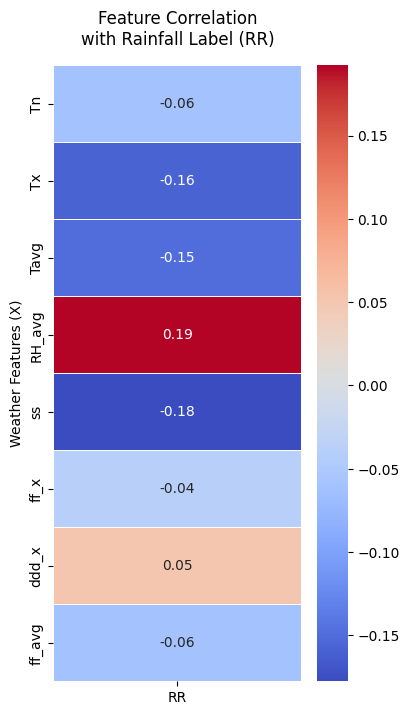

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 10))
full_correlation = df.corr(numeric_only=True)
label_corelation = full_correlation[['RR']].drop(index=['RR', 'station_id'])
plt.figure(figsize=(4, 8))
sns.heatmap(
    label_corelation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    cbar=True,
    linewidths=0.5
)

plt.title('Feature Correlation\nwith Rainfall Label (RR)', fontsize=12, pad=15)
plt.ylabel('Weather Features (X)')
plt.show()

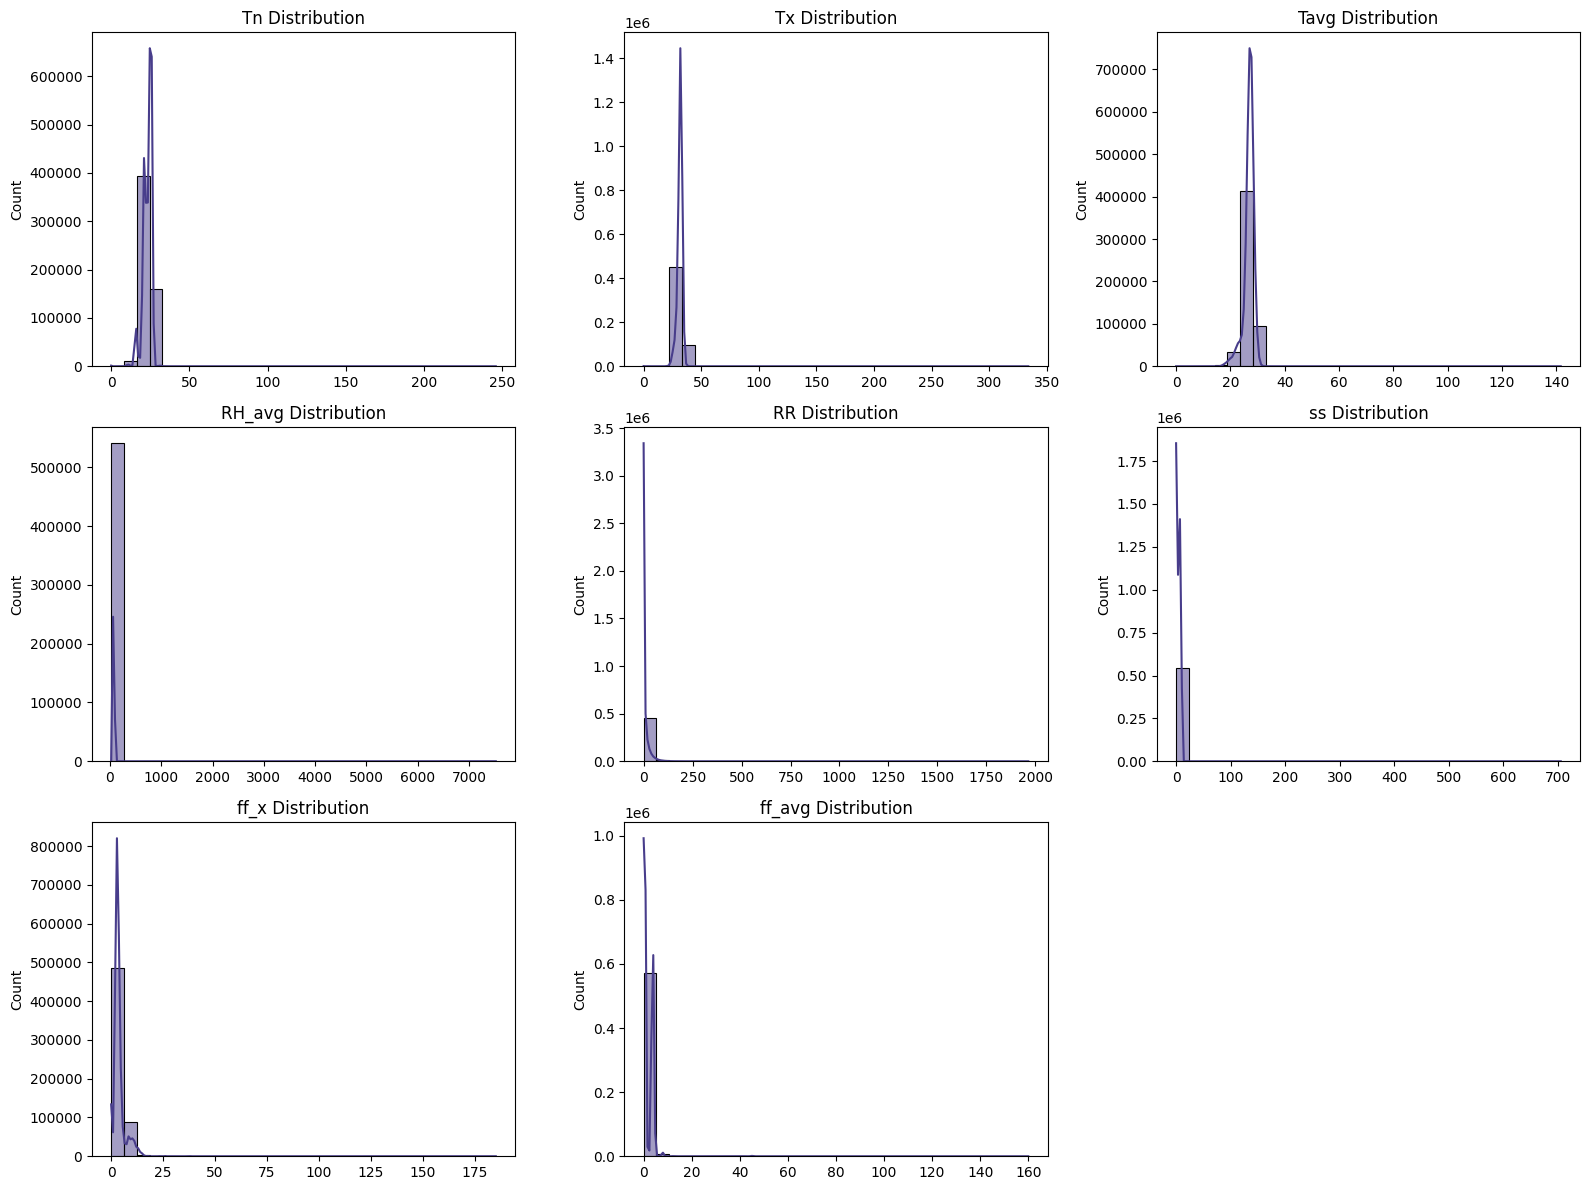

In [8]:
features_to_plot = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ff_avg']


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):

    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='darkslateblue', bins=30)
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel('')


axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

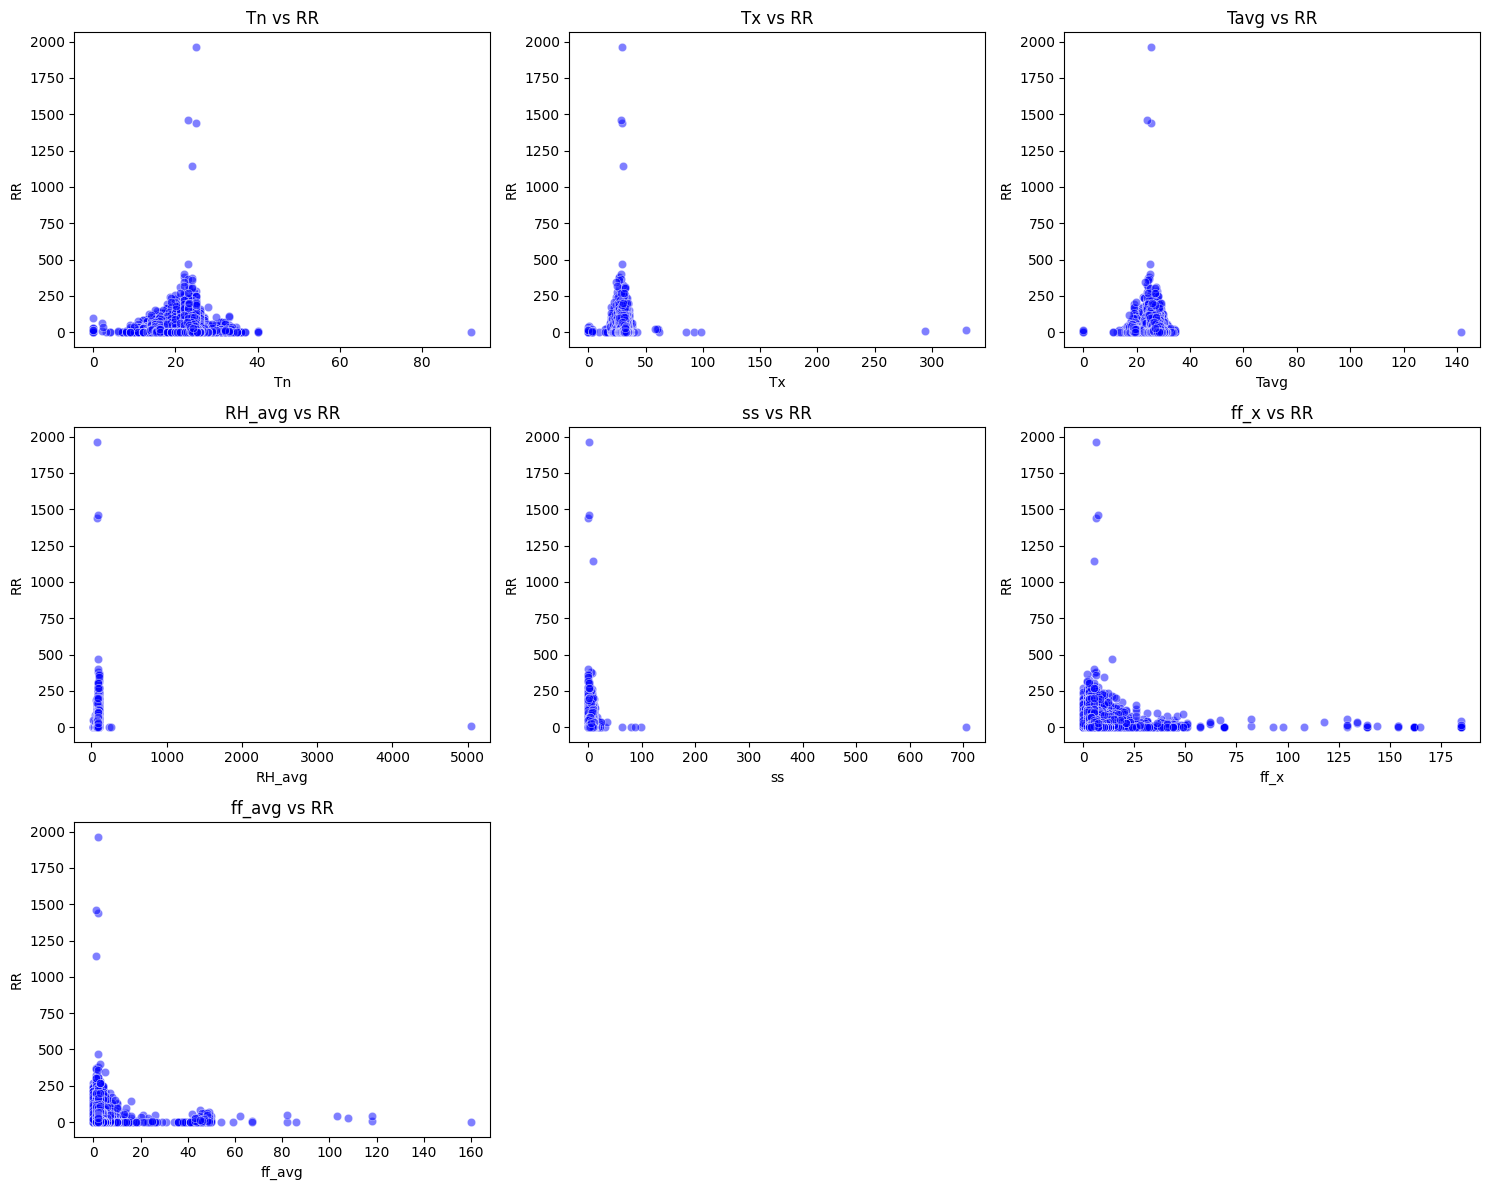

In [9]:
features = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'ss', 'ff_x', 'ff_avg']
label = 'RR'

# Mengatur ukuran figure (keseluruhan kanvas)
plt.figure(figsize=(15, 12))

# Looping melalui semua fitur untuk membuat subplot masing-masing
for i, feature in enumerate(features, 1):
    # Membuat grid subplot ukuran 3 baris x 3 kolom
    plt.subplot(3, 3, i)

    # Membuat scatter plot
    sns.scatterplot(data=df, x=feature, y=label, alpha=0.5, color='b')

    # Memberi judul dan label pada sumbu
    plt.title(f'{feature} vs {label}')
    plt.xlabel(feature)
    plt.ylabel(label)

# Menyesuaikan jarak antar subplot agar tidak tumpang tindih
plt.tight_layout()

# Menampilkan plot
plt.show()

# Data Preprocessing

ini Scrubbing sama handling missing values

In [10]:
import numpy as np
import pandas as pd
# KODE BARU (Gantikan seluruh isi Cell 4 dengan ini):
print("Missing Values Sebelum Imputasi:")
print(df.isnull().sum())

# Langkah 1: Mengubah date menjadi datetime dan mengurutkan data secara kronologis
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df = df.sort_values(by=['station_id', 'date']).reset_index(drop=True)

# 1. Bersihkan Suhu Minimum (Tn): Normalnya di Indonesia berkisar 15 - 35 derajat
df.loc[(df['Tn'] < 15) | (df['Tn'] > 35), 'Tn'] = np.nan
df.loc[(df['Tavg'] < 15) | (df['Tavg'] > 40), 'Tavg'] = np.nan
# 2. Bersihkan Suhu Maksimum (Tx): Normalnya 20 - 45 derajat
df.loc[(df['Tx'] < 20) | (df['Tx'] > 45), 'Tx'] = np.nan

# 3. Bersihkan Kecepatan Angin Maksimum (ff_x): Batasi jika ada angka ekstrem
df.loc[(df['ff_x'] < 0) | (df['ff_x'] > 40), 'ff_x'] = np.nan

# 4. Batasan fisis lainnya
df.loc[df['RH_avg'] > 100, 'RH_avg'] = np.nan
df.loc[df['ss'] > 12, 'ss'] = np.nan
df.loc[df['RR'] > 500, 'RR'] = np.nan

# Langkah 2: Imputasi Fitur Numerik menggunakan Interpolasi Linear per Stasiun
kolom_numerik = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ddd_x', 'ff_avg']
df[kolom_numerik] = df.groupby('station_id')[kolom_numerik].transform(
    lambda x: x.interpolate(method='linear', limit=7, limit_direction='forward')
)

# Langkah 3: Imputasi Fitur Kategorik (Arah Angin) menggunakan Forward/Backward Fill per Stasiun
df['ddd_car'] = df.groupby('station_id')['ddd_car'].transform(
    lambda x: x.ffill(limit=7)
)
df = df.dropna(subset=kolom_numerik)

print("\nMissing Values Setelah Imputasi:")
print(df.isnull().sum())

Missing Values Sebelum Imputasi:
date               0
Tn             23383
Tx             37736
Tavg           45105
RH_avg         48182
RR            125384
ss             43721
ff_x           10214
ddd_x          13128
ff_avg         10127
ddd_car        13739
station_id         0
dtype: int64

Missing Values Setelah Imputasi:
date             0
Tn               0
Tx               0
Tavg             0
RH_avg           0
RR               0
ss               0
ff_x             0
ddd_x            0
ff_avg           0
ddd_car       1341
station_id       0
dtype: int64


In [11]:
print(f"Shape data setelah perbaikan missing value: {df.shape}")

Shape data setelah perbaikan missing value: (518571, 12)


Korelasi data

<Figure size 1400x1000 with 0 Axes>

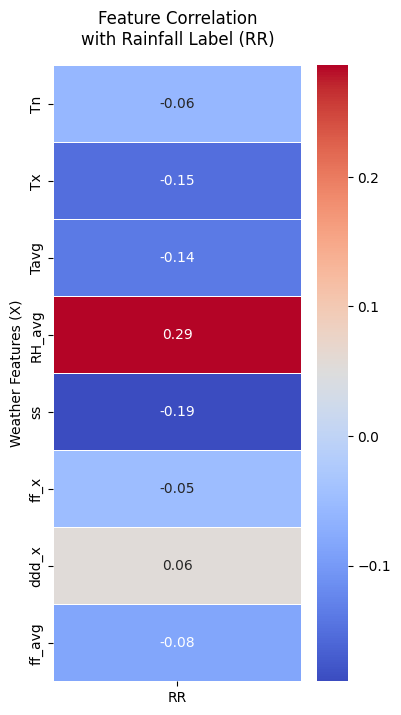

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 10))
full_correlation = df.corr(numeric_only=True)
label_corelation = full_correlation[['RR']].drop(index=['RR', 'station_id'])
plt.figure(figsize=(4, 8))
sns.heatmap(
    label_corelation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    cbar=True,
    linewidths=0.5
)

plt.title('Feature Correlation\nwith Rainfall Label (RR)', fontsize=12, pad=15)
plt.ylabel('Weather Features (X)')
plt.show()

In [13]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Hubungannya dengan target: Mari kita lihat rata-rata curah hujan tiap bulannya
print("Rata-rata curah hujan (RR) per bulan:")
print(df.groupby('month')['RR'].mean())

Rata-rata curah hujan (RR) per bulan:
month
1     10.737939
2     10.352723
3      9.735928
4      9.533793
5      8.484962
6      7.356428
7      6.280684
8      5.328318
9      6.032122
10     7.179349
11     9.780173
12    11.302515
Name: RR, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20524\3357581521.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='RR', data=monthly_rain, palette='Blues_r')


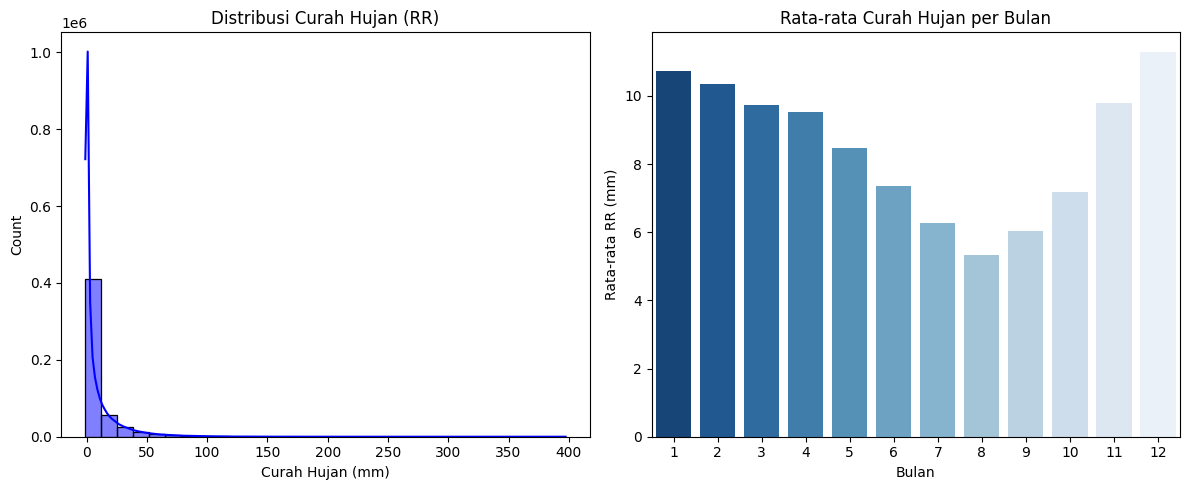

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['RR'], bins=30, kde=True, color='blue')
plt.title('Distribusi Curah Hujan (RR)')
plt.xlabel('Curah Hujan (mm)')

# 2. Plot Rata-rata Curah Hujan Per Bulan (Melihat Pola Musiman)
plt.subplot(1, 2, 2)
monthly_rain = df.groupby('month')['RR'].mean().reset_index()
sns.barplot(x='month', y='RR', data=monthly_rain, palette='Blues_r')
plt.title('Rata-rata Curah Hujan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata RR (mm)')

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20524\710823117.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ddd_car', order=df['ddd_car'].value_counts().index, palette='viridis')


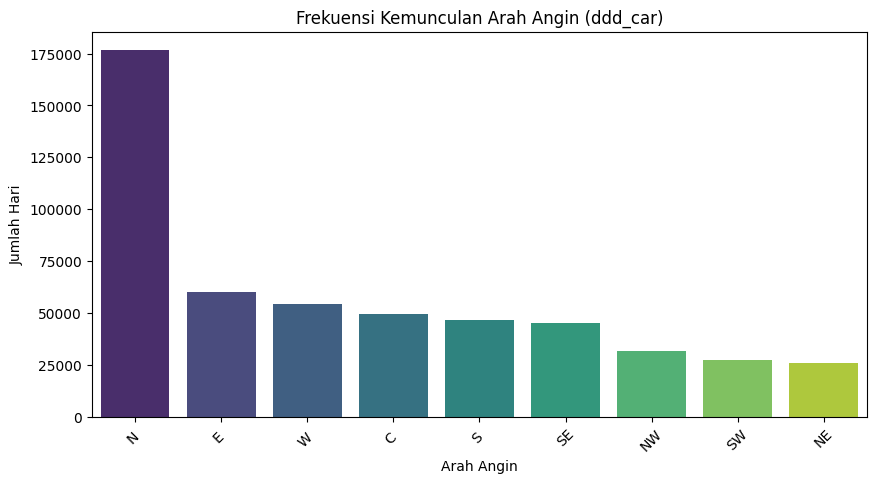

In [15]:
plt.figure(figsize=(10, 5))
# Urutkan arah angin dari yang paling sering muncul
sns.countplot(data=df, x='ddd_car', order=df['ddd_car'].value_counts().index, palette='viridis')
plt.title('Frekuensi Kemunculan Arah Angin (ddd_car)')
plt.xlabel('Arah Angin')
plt.ylabel('Jumlah Hari')
plt.xticks(rotation=45)
plt.show()

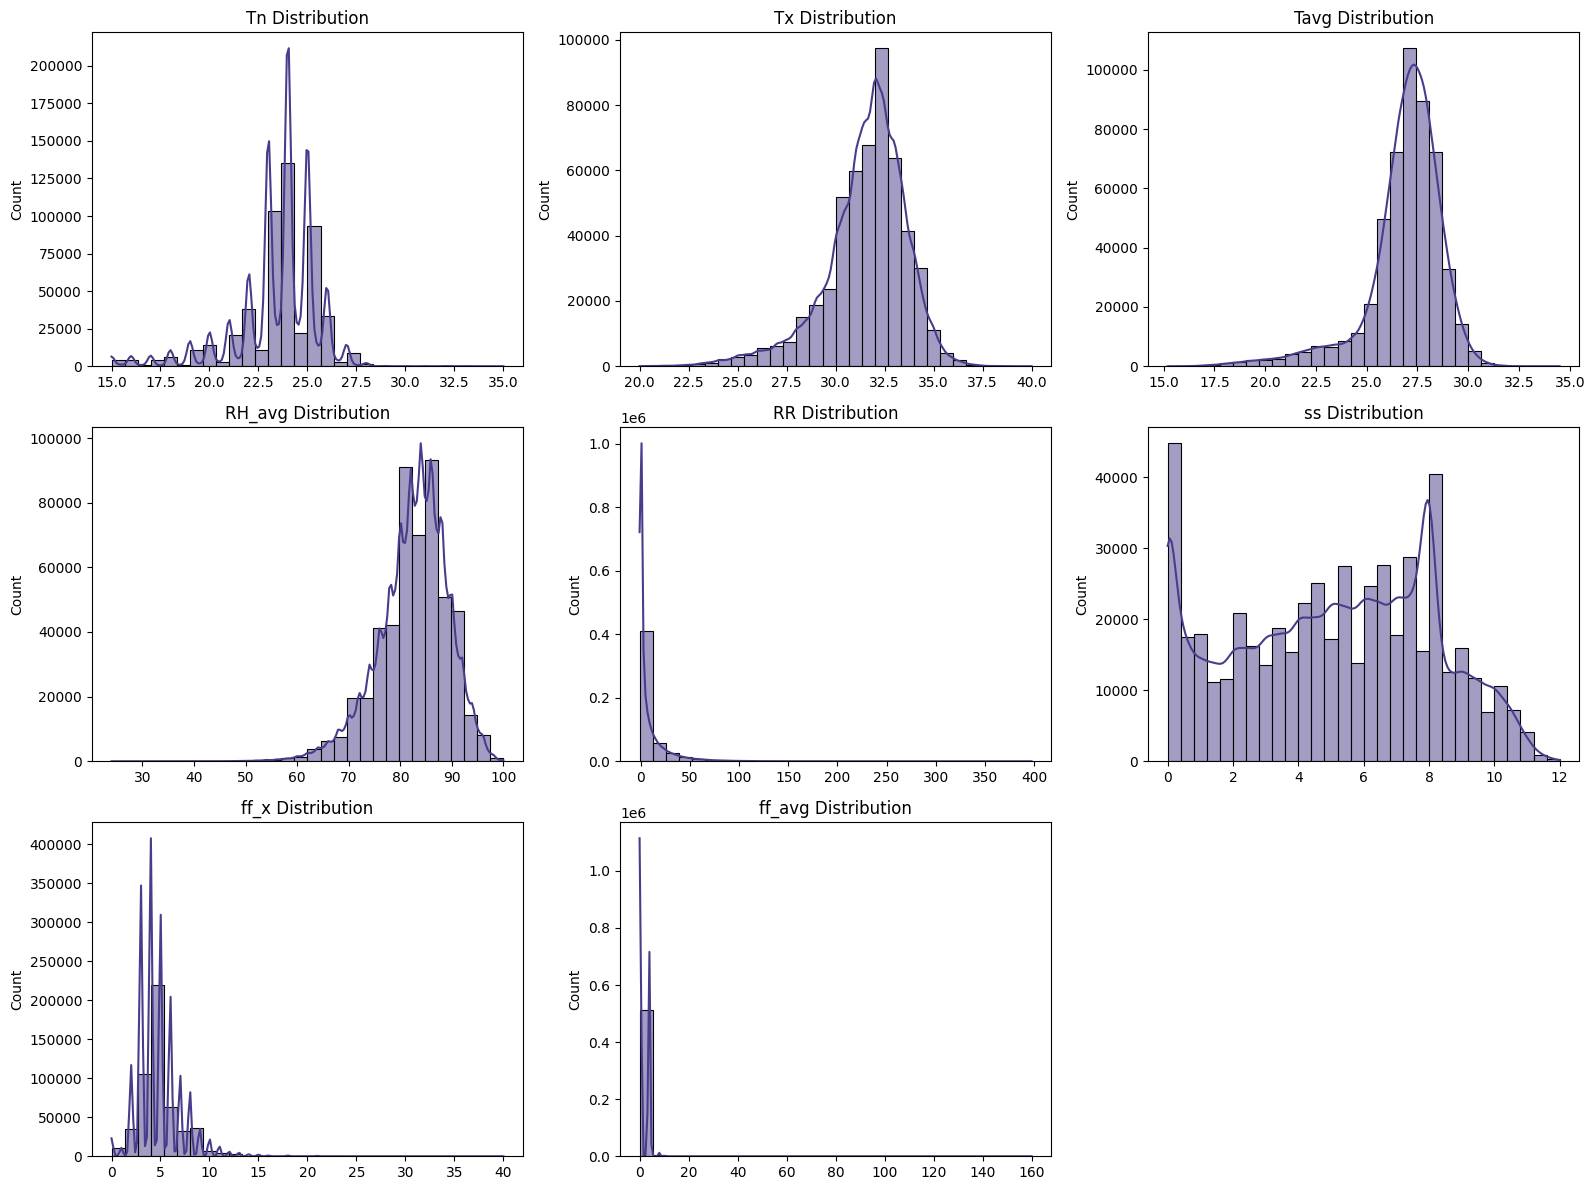

In [16]:
features_to_plot = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ff_avg']


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):

    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='darkslateblue', bins=30)
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel('')


axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

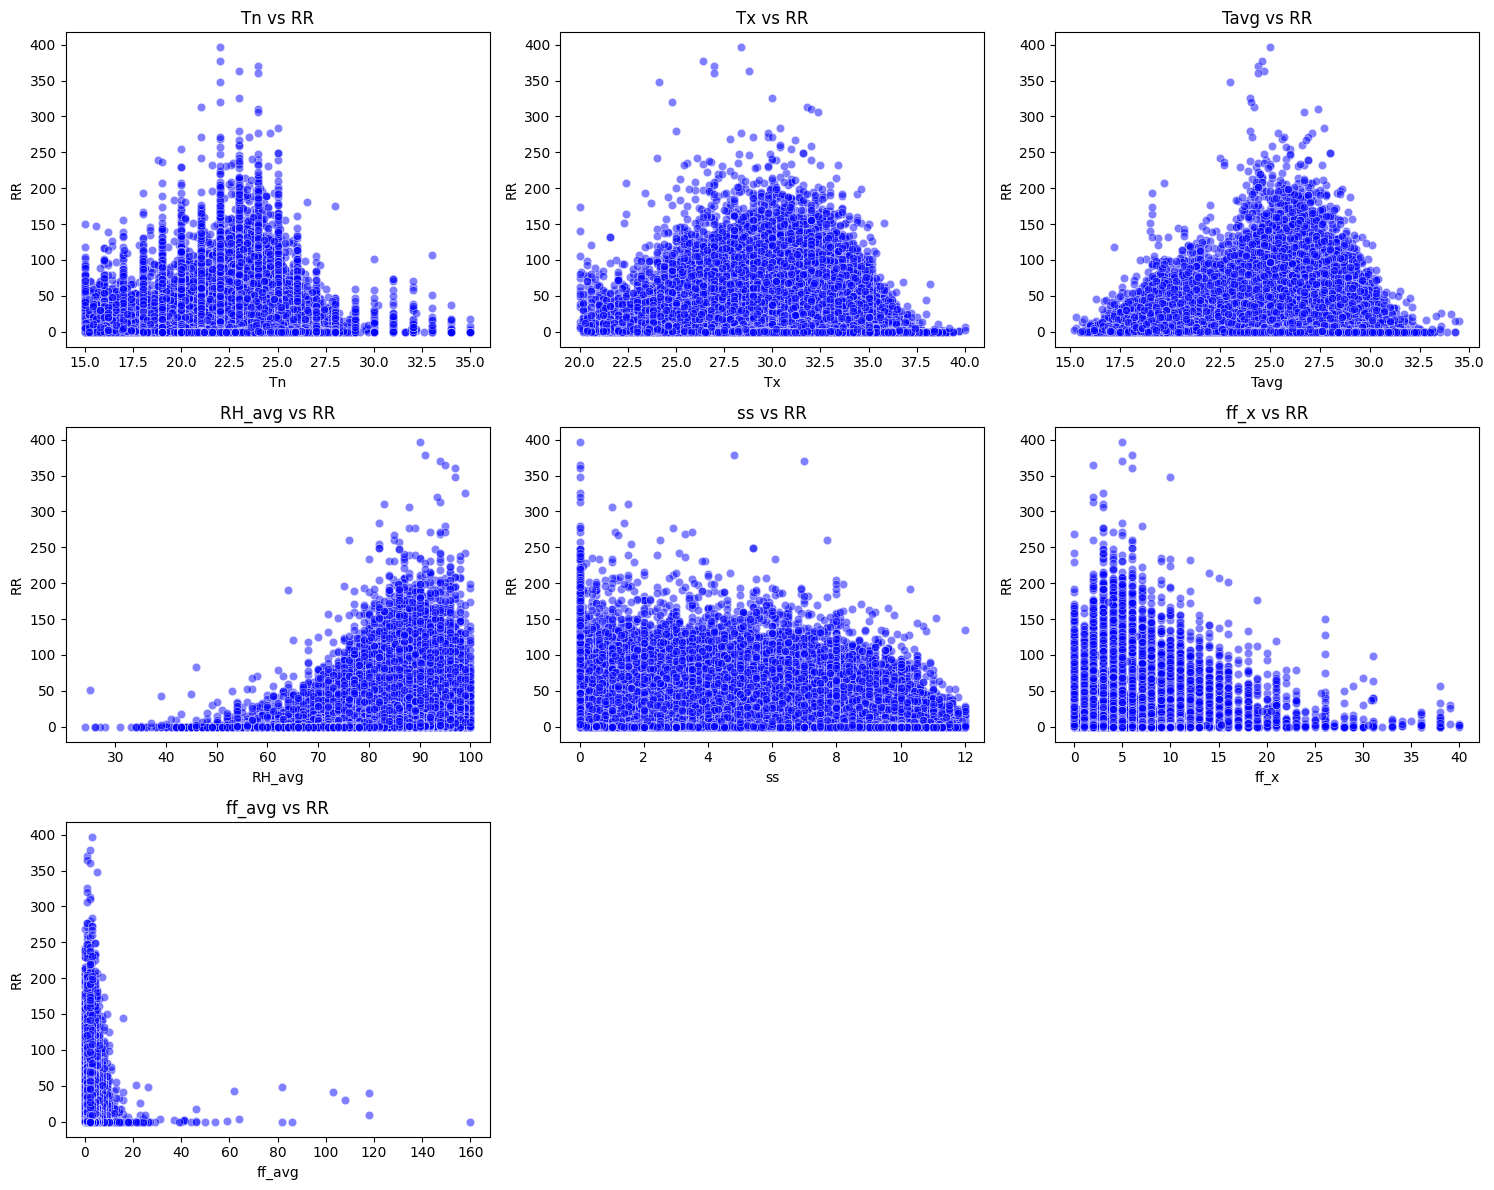

In [17]:
features = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'ss', 'ff_x', 'ff_avg']
label = 'RR'

# Mengatur ukuran figure (keseluruhan kanvas)
plt.figure(figsize=(15, 12))

# Looping melalui semua fitur untuk membuat subplot masing-masing
for i, feature in enumerate(features, 1):
    # Membuat grid subplot ukuran 3 baris x 3 kolom
    plt.subplot(3, 3, i)

    # Membuat scatter plot
    sns.scatterplot(data=df, x=feature, y=label, alpha=0.5, color='b')

    # Memberi judul dan label pada sumbu
    plt.title(f'{feature} vs {label}')
    plt.xlabel(feature)
    plt.ylabel(label)

# Menyesuaikan jarak antar subplot agar tidak tumpang tindih
plt.tight_layout()

# Menampilkan plot
plt.show()


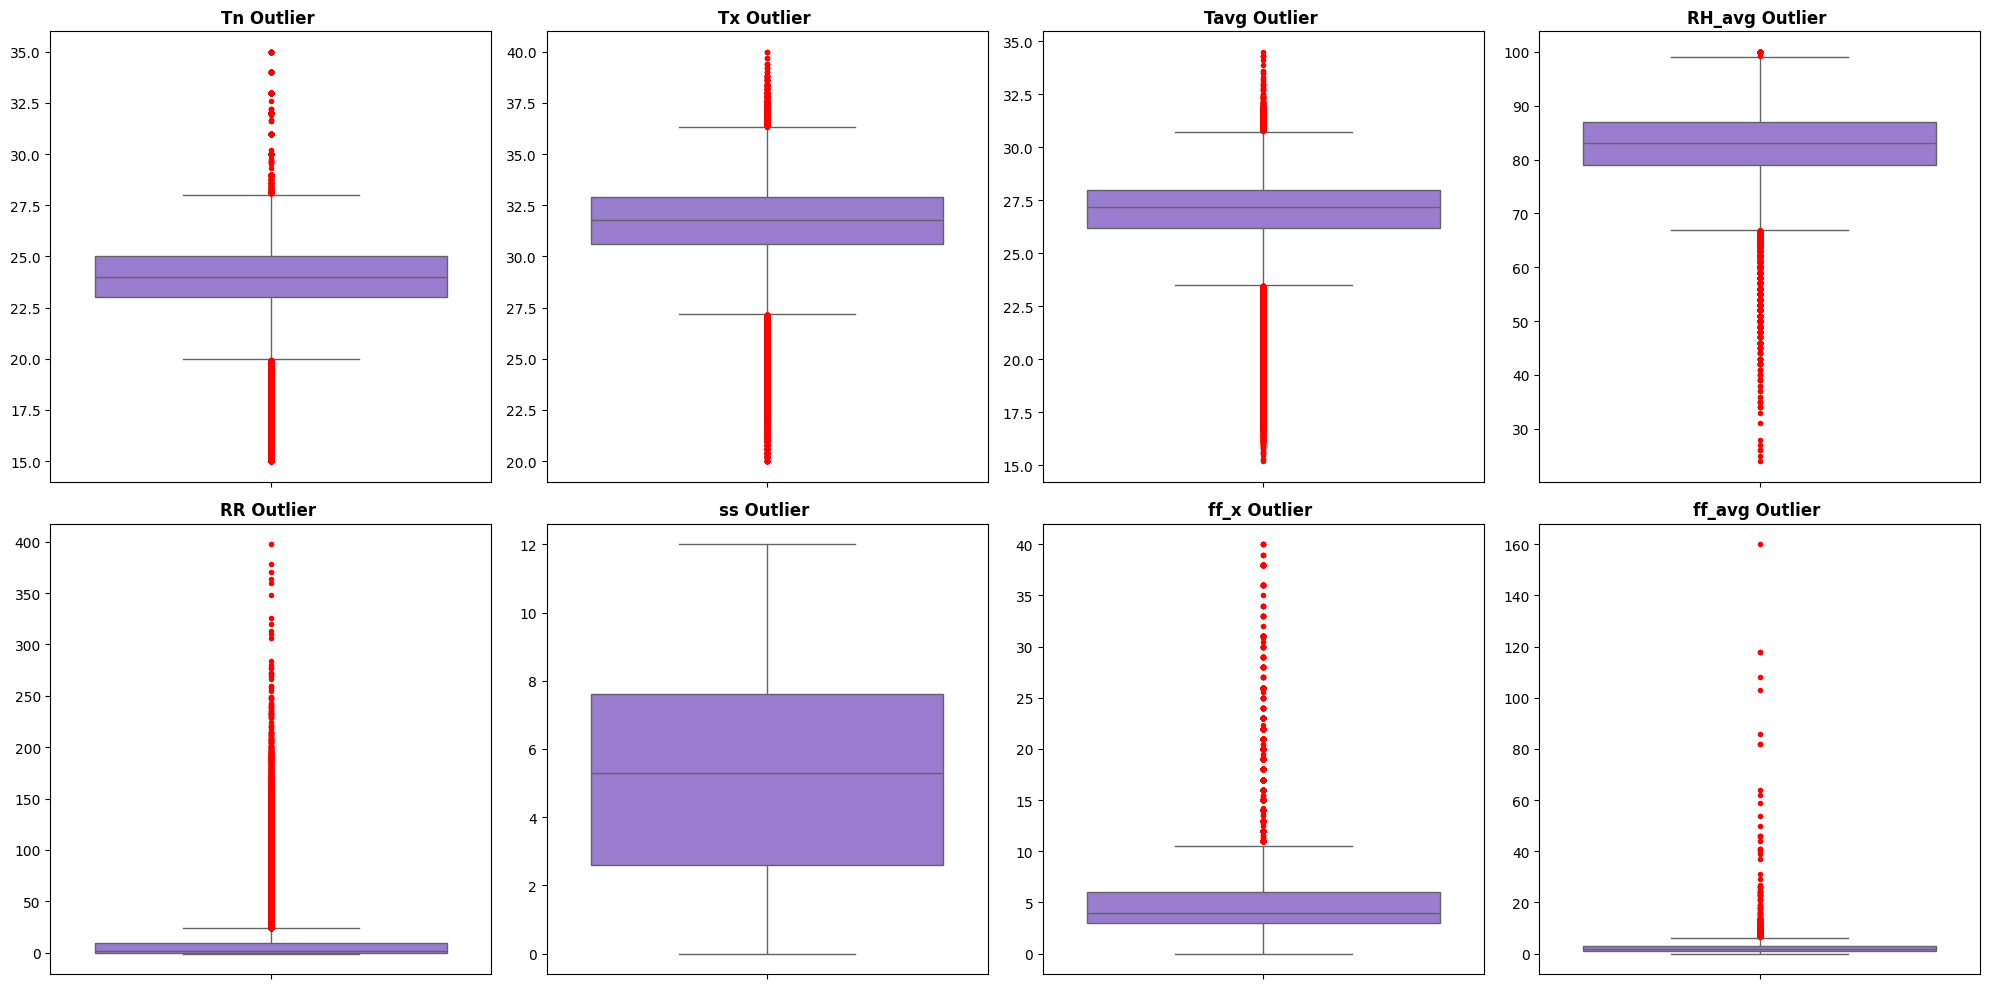

In [18]:
features_to_box = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ff_avg']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_box):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color='mediumpurple',
        flierprops={'markerfacecolor': 'red', 'markersize': 4, 'markeredgecolor': 'none'}
    )
    axes[i].set_title(f'{col} Outlier ', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Encoding

In [19]:
ddd_car_encoded = pd.get_dummies(df['ddd_car'], prefix='ddd_car', dtype=int)
df = pd.concat([df, ddd_car_encoded], axis=1)
df = df.drop('ddd_car', axis=1)

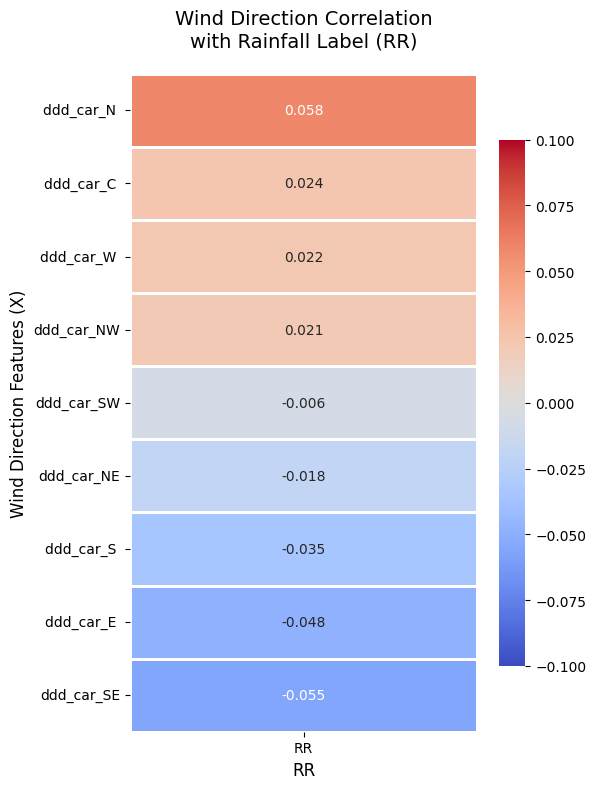

In [20]:
# 1. Saring HANYA kolom hasil One-Hot Encoding arah mata angin
wind_features = [col for col in df.columns if col.startswith('ddd_car_')]

# 2. Hitung matriks korelasi antara arah angin dan RR, lalu ambil kolom 'RR' saja
# Kita gunakan .drop('RR') agar baris RR vs RR tidak ikut muncul
correlation_wind = df[wind_features + ['RR']].corr()[['RR']].drop('RR')

# 3. Urutkan berdasarkan nilai korelasi terbesar ke terkecil (opsional, agar lebih rapi dibaca)
correlation_wind = correlation_wind.sort_values(by='RR', ascending=False)

# 4. Atur ukuran kanvas (disesuaikan dengan jumlah arah mata angin yang muncul)
plt.figure(figsize=(6, 8))

# 5. Gambar Heatmap Khusus Arah Mata Angin
sns.heatmap(
    correlation_wind,
    annot=True,             # Menampilkan angka korelasi
    cmap='coolwarm',        # Gradasi warna biru-putih-merah
    fmt=".3f",              # Tiga angka di belakang koma (karena korelasi kategori biasanya kecil)
    linewidths=0.8,         # Garis pembatas antar kotak
    linecolor='white',
    vmin=-0.1,              # Batas bawah diperketat agar kontras warna lebih sensitif
    vmax=0.1,               # Batas atas diperketat karena korelasi arah angin biasanya tipis
    cbar_kws={"shrink": 0.8}
)

# 6. Konfigurasi Label dan Judul
plt.title('Wind Direction Correlation\nwith Rainfall Label (RR)', fontsize=14, pad=20, fontweight='medium')
plt.ylabel('Wind Direction Features (X)', fontsize=12)
plt.xlabel('RR', fontsize=12)

# Mengatur posisi estetika agar tidak terpotong
plt.tight_layout()

# 7. Tampilkan Grafiknya
plt.show()

Standarization/Normalization
- Tn normalisasinya  z-score scalling
- Tx normalisasinya  z-score scalling
- Tavg normalisasinya  z-score scalling
- RH_avg normalisasinya pake z-score scalling
- RR normalisasinya pake log scalling
- SS normalisasinya pake linear scalling
- ff_x normalisasinya Z-score
- ff_avg normalisasinya Z-score


TranTest Split sama Lasso yang L1


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


✅ Fitur X telah di-scale: Z-score untuk suhu/angin & Linear untuk SS.
✅ Label Y telah aman dalam bentuk Log-Scale (tidak ada nilai negatif).

=== FITUR YANG DIPILIH LASSO ===
- Tn
- Tx
- Tavg
- RH_avg
- ss
- ff_x
- ddd_x
- ff_avg
- month
- year
- ddd_car_E 
- ddd_car_N 
- ddd_car_NW
- ddd_car_S 
- ddd_car_SE
- ddd_car_W 

Total fitur terpilih: 16 dari 19



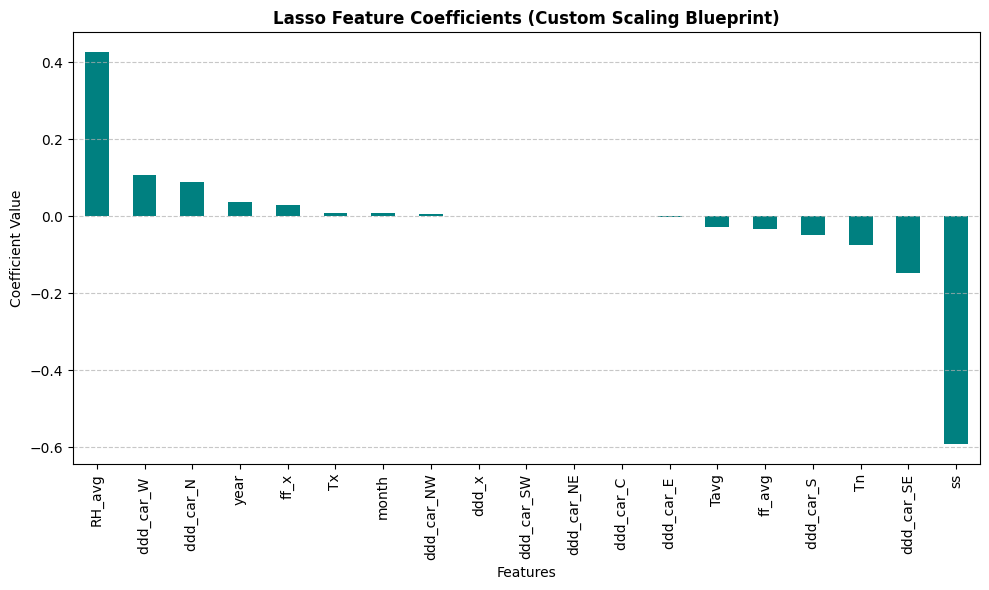

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#=====================================================================
# 1. PERSIAPAN DATA & TARGET LOG SCALING (Sesuai Aturan Baru)
# =====================================================================
y = np.log1p(df["RR"])
X = df.drop(columns=["date", "RR", "station_id"])

for col in X.select_dtypes(include="bool").columns:
    X[col] = X[col].astype(int)

X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)

combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)

X = combined_data.drop(columns=["RR"])
y = combined_data["RR"]

# =====================================================================
# 2. SPLIT KRONOLOGIS 50% / 25% / 25% (Rasio Permintaan Dosen)
# =====================================================================
total_rows = len(X)
batas_train = int(total_rows * 0.50)
batas_val = int(total_rows * 0.75)

X_train, y_train = X.iloc[:batas_train].copy(), y.iloc[:batas_train].copy()
X_val, y_val     = X.iloc[batas_train:batas_val].copy(), y.iloc[batas_train:batas_val].copy()
X_test, y_test   = X.iloc[batas_val:].copy(), y.iloc[batas_val:].copy()

# =====================================================================
# 3. PROSES MULTI-SCALING FITUR X (Mencegah Data Leakage)
# =====================================================================
fitur_zscore = ["Tn", "Tx", "Tavg", "RH_avg", "ff_x", "ff_avg"]
fitur_linear = ["ss"]

scaler_zscore = StandardScaler()
scaler_linear = MinMaxScaler()

X_train[fitur_zscore] = scaler_zscore.fit_transform(X_train[fitur_zscore])
X_train[fitur_linear] = scaler_linear.fit_transform(X_train[fitur_linear])

X_val[fitur_zscore] = scaler_zscore.transform(X_val[fitur_zscore])
X_val[fitur_linear] = scaler_linear.transform(X_val[fitur_linear])

X_test[fitur_zscore] = scaler_zscore.transform(X_test[fitur_zscore])
X_test[fitur_linear] = scaler_linear.transform(X_test[fitur_linear])

print("✅ Fitur X telah di-scale: Z-score untuk suhu/angin & Linear untuk SS.")
print("✅ Label Y telah aman dalam bentuk Log-Scale (tidak ada nilai negatif).\n")

# =====================================================================
# 4. TRAINING LASSO REGRESSION FOR FEATURE SELECTION
# =====================================================================
lasso = Lasso(alpha=0.001, random_state=42)
lasso.fit(X_train, y_train)

feature_coefficients = pd.Series(lasso.coef_, index=X.columns)
selected_features = feature_coefficients[feature_coefficients != 0].index.tolist()

print("=== FITUR YANG DIPILIH LASSO ===")
for feature in selected_features:
    print(f"- {feature}")
print(f"\nTotal fitur terpilih: {len(selected_features)} dari {len(X.columns)}\n")

X_train_lasso = X_train[selected_features]
X_val_lasso = X_val[selected_features]
X_test_lasso = X_test[selected_features]
# =====================================================================
# 5. VISUALISASI KOEFISIEN FITUR
# =====================================================================
plt.figure(figsize=(10, 6))
feature_coefficients.sort_values(ascending=False).plot(kind="bar", color="teal")
plt.title("Lasso Feature Coefficients (Custom Scaling Blueprint)", fontsize=12, fontweight='bold')
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

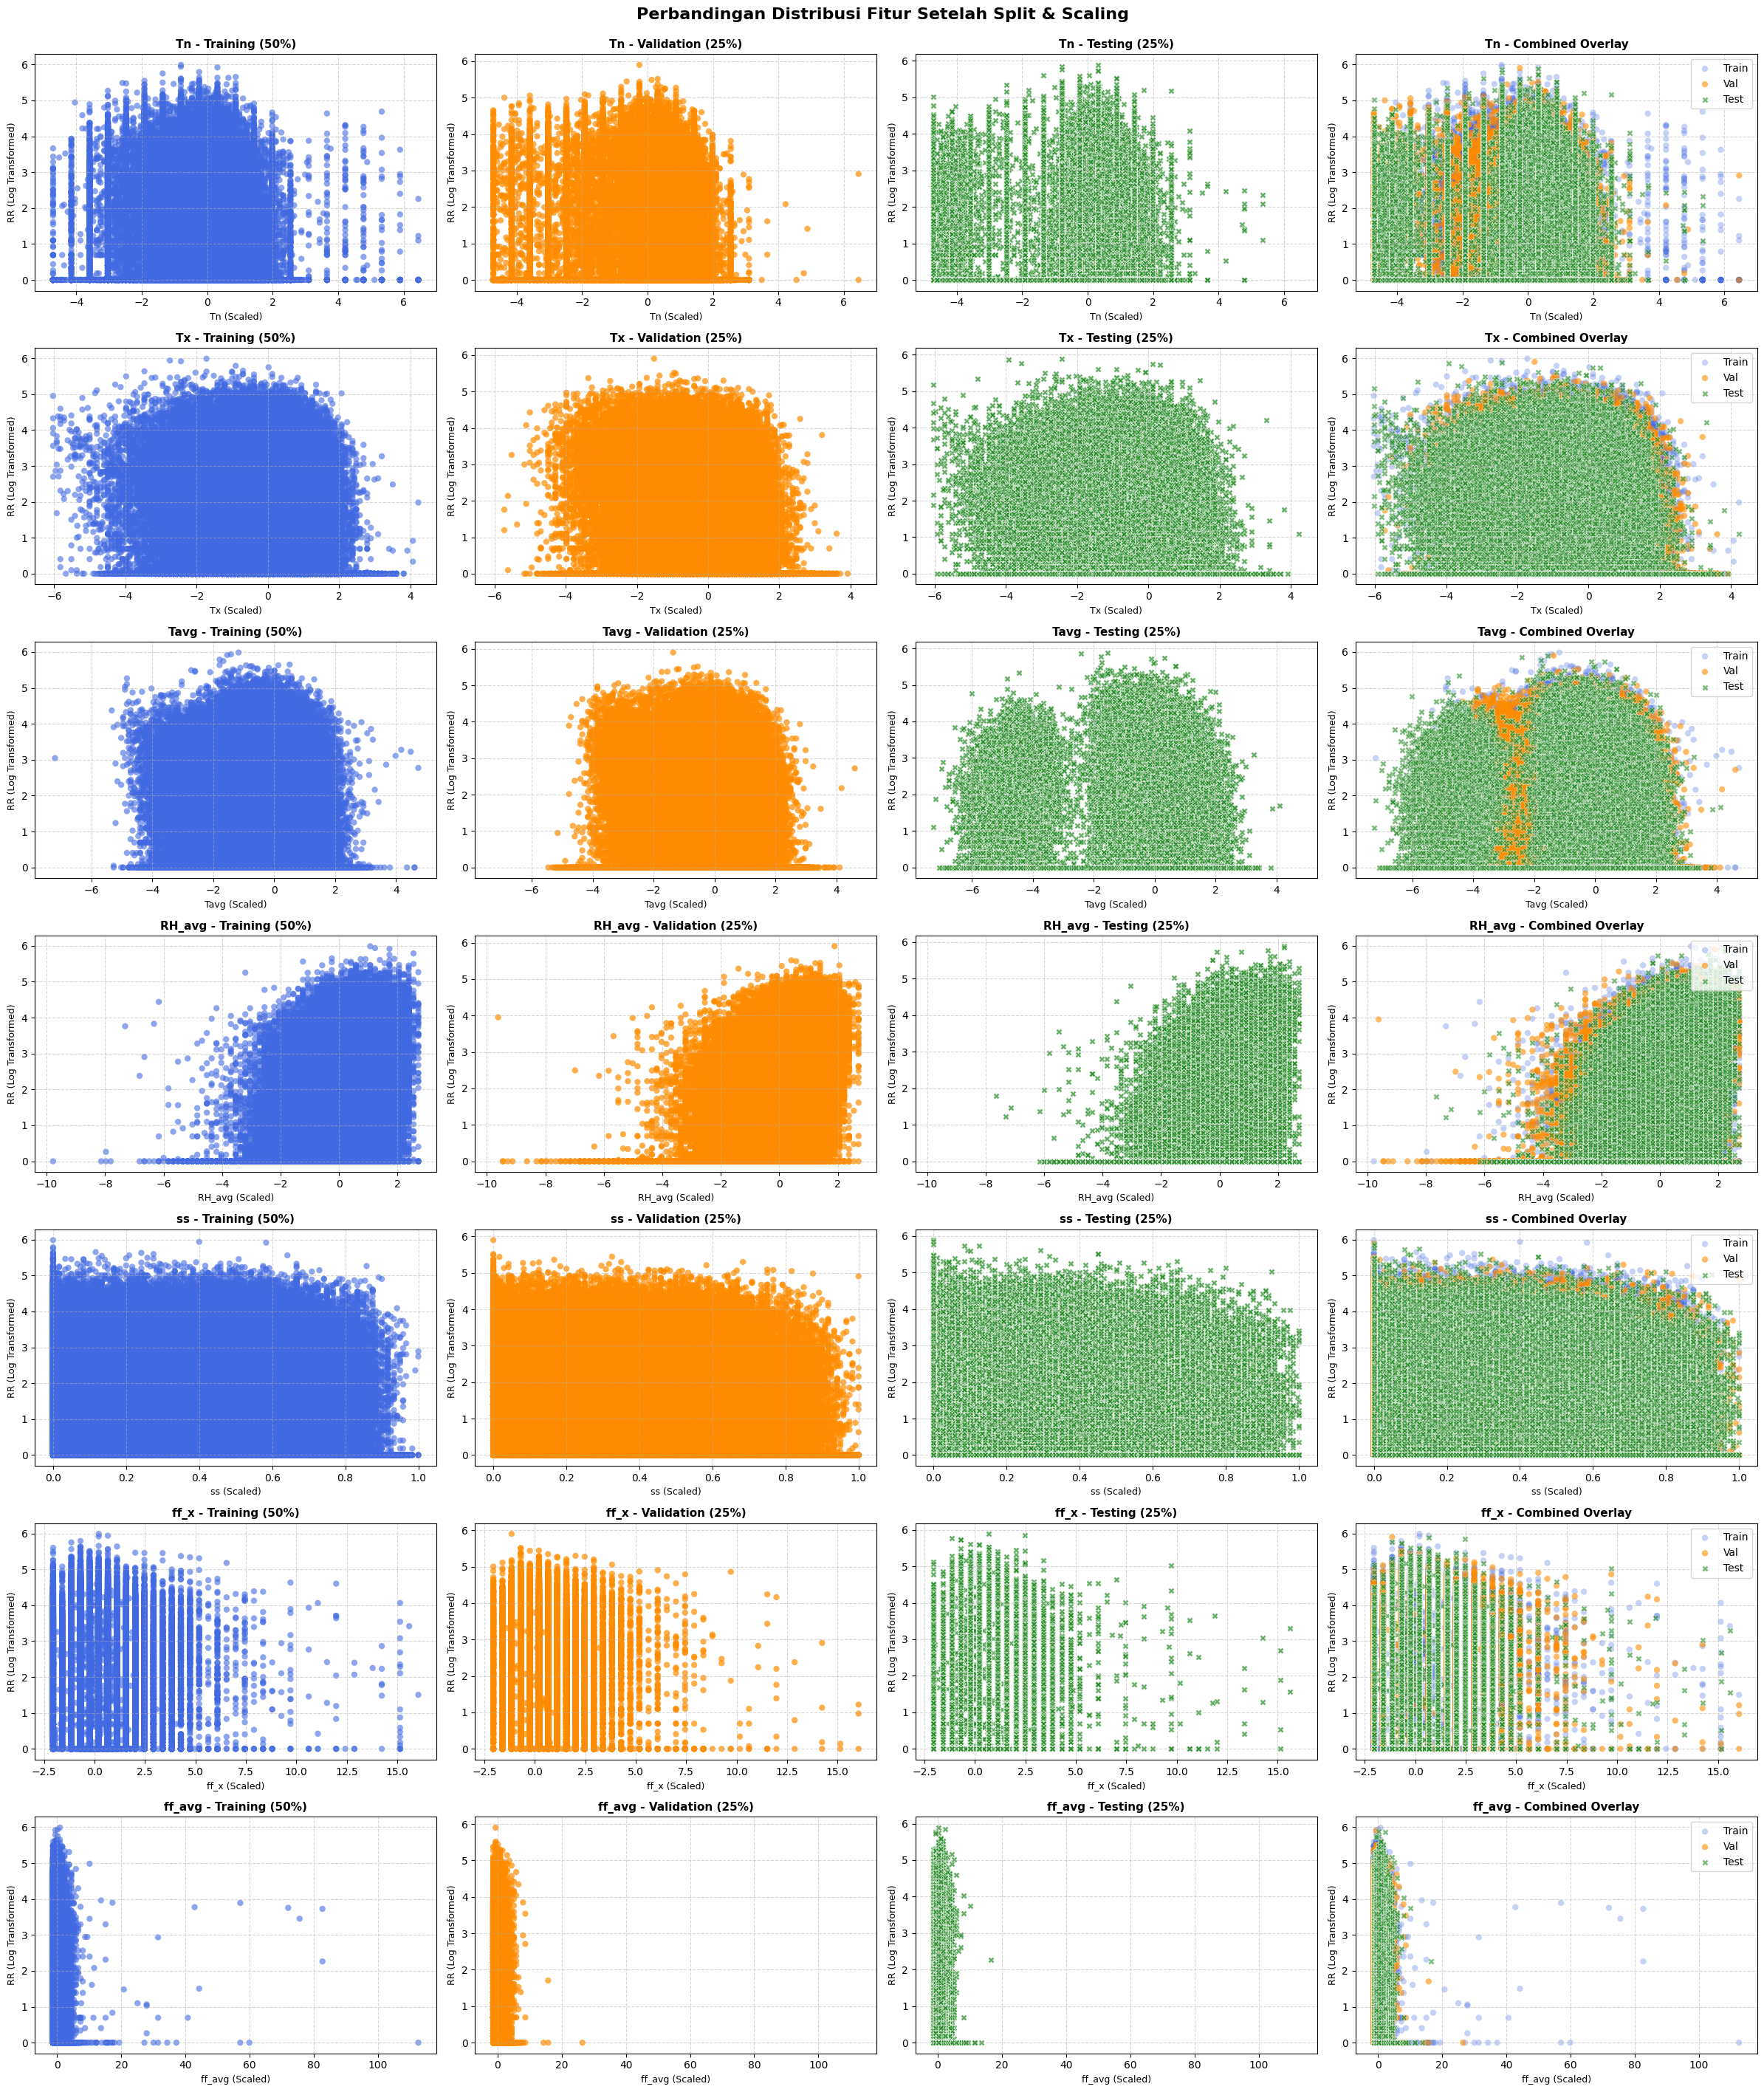

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ["Tn", "Tx", "Tavg", "RH_avg", "ss", "ff_x", "ff_avg"]
label = "RR"

# PERBAIKAN: Tambahkan sharex='row' agar rentang sumbu X per baris fitur dipaksa SAMA PERSIS
fig, axes = plt.subplots(
    nrows=len(features_to_plot),
    ncols=4,
    figsize=(24, 4 * len(features_to_plot)),
    sharex='row'  # <--- Kunci sinkronisasi skala sumbu X
)

for idx, feature in enumerate(features_to_plot):

    # ---- KOLOM 1: KHUSUS TRAINING (50%) ----
    sns.scatterplot(
        x=X_train[feature],
        y=y_train,
        ax=axes[idx, 0],
        color="royalblue",
        alpha=0.6,
        edgecolor="none",
    )
    axes[idx, 0].set_title(f"{feature} - Training (50%)", fontsize=11, fontweight="bold")

    # ---- KOLOM 2: KHUSUS VALIDATION (25%) ----
    sns.scatterplot(
        x=X_val[feature],
        y=y_val,
        ax=axes[idx, 1],
        color="darkorange",
        alpha=0.7,
        edgecolor="none",
    )
    axes[idx, 1].set_title(f"{feature} - Validation (25%)", fontsize=11, fontweight="bold")

    # ---- KOLOM 3: KHUSUS TESTING (25%) ----
    sns.scatterplot(
        x=X_test[feature],
        y=y_test,
        ax=axes[idx, 2],
        color="forestgreen",
        alpha=0.7,
        marker="X",
    )
    axes[idx, 2].set_title(f"{feature} - Testing (25%)", fontsize=11, fontweight="bold")

    # ---- KOLOM 4: GABUNGAN UNTUK PERBANDINGAN ----
    sns.scatterplot(
        x=X_train[feature],
        y=y_train,
        ax=axes[idx, 3],
        color="royalblue",
        alpha=0.3,
        label="Train",
        edgecolor="none",
    )
    sns.scatterplot(
        x=X_val[feature],
        y=y_val,
        ax=axes[idx, 3],
        color="darkorange",
        alpha=0.6,
        label="Val",
        edgecolor="none",
    )
    sns.scatterplot(
        x=X_test[feature],
        y=y_test,
        ax=axes[idx, 3],
        color="forestgreen",
        alpha=0.6,
        label="Test",
        marker="X",
    )
    axes[idx, 3].set_title(f"{feature} - Combined Overlay", fontsize=11, fontweight="bold")
    axes[idx, 3].legend(loc="upper right", frameon=True)

    # ---- PENGATURAN LABEL SUMBU UNTUK SEMUA SUBPLOT ----
    for col_idx in range(4):
        axes[idx, col_idx].set_xlabel(f"{feature} (Scaled)", fontsize=9)
        axes[idx, col_idx].set_ylabel(f"{label} (Log Transformed)", fontsize=9)
        axes[idx, col_idx].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
# Memberikan judul besar di atas kanvas
plt.suptitle("Perbandingan Distribusi Fitur Setelah Split & Scaling", fontsize=16, fontweight="bold", y=1.01)
plt.show()

# Algo

Gradient Boosting

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
gb_model_standar = GradientBoostingRegressor(
    n_estimators=500,          # Pohon diperbanyak agar prediksi lebih matang
    learning_rate=0.1,        # Sedikit dilambatkan karena pohonnya banyak
    max_depth=7,               # Pohon lebih dalam (berani mengeksplor interaksi rumit)
    min_samples_leaf=5,        # Rem agar ujung daun tidak menghafal data palsu
    subsample=0.8,             # Pakai 80% data acak tiap pohon
    max_features='sqrt',       # TRIK RAHASIA: Ambil fitur acak tiap split agar tidak overfit
    random_state=67
)

# =====================================================================
# 2. PELATIHAN MODEL
# =====================================================================
print("⏳ Sedang melatih Gradient Boosting Standar...")
gb_model_standar.fit(X_train_lasso, y_train)
print("✅ Pelatihan selesai!\n")

# =====================================================================
# 3. PREDIKSI & KEMBALIKAN KE SKALA MILIMETER ASLI (INVERSE LOG)
# =====================================================================
y_pred_log_gb = gb_model_standar.predict(X_val_lasso)
y_pred_asli_gb = np.expm1(y_pred_log_gb)
y_val_asli = np.expm1(y_val)

# =====================================================================
# 4. EVALUASI (RAPOR GRADIENT BOOSTING)
# =====================================================================
mae_gb = mean_absolute_error(y_val_asli, y_pred_asli_gb)
rmse_gb = np.sqrt(mean_squared_error(y_val_asli, y_pred_asli_gb))
r2_gb = r2_score(y_val_asli, y_pred_asli_gb)

print("=== RAPOR GRADIENT BOOSTING (STANDAR) ===")
print(f"MAE  (Rata-rata Meleset)     : {mae_gb:.2f} mm")
print(f"RMSE (Meleset Terburuk)      : {rmse_gb:.2f} mm")
print(f"R-squared (Skor Kecerdasan)  : {r2_gb:.4f}")

⏳ Sedang melatih Gradient Boosting Standar...
✅ Pelatihan selesai!

=== RAPOR GRADIENT BOOSTING (STANDAR) ===
MAE  (Rata-rata Meleset)     : 7.14 mm
RMSE (Meleset Terburuk)      : 15.54 mm
R-squared (Skor Kecerdasan)  : 0.0193


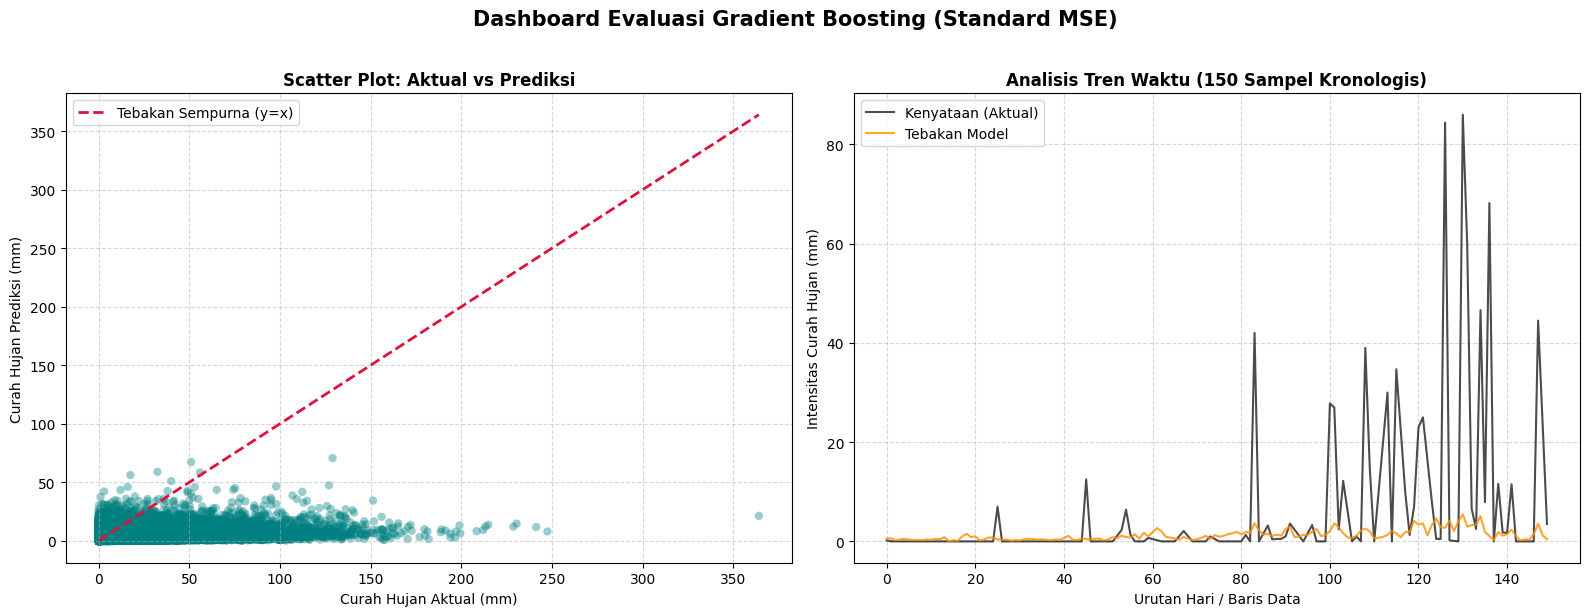

In [24]:
import matplotlib.pyplot as plt

# Pastikan data berupa numpy array
y_val_asli_arr = np.array(y_val_asli)
y_pred_asli_arr = np.array(y_pred_asli_gb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFIK 1: SCATTER PLOT ---
axes[0].scatter(y_val_asli_arr, y_pred_asli_arr, alpha=0.4, color='teal', edgecolors='none')
max_val = max(np.max(y_val_asli_arr), np.max(y_pred_asli_arr))
axes[0].plot([0, max_val], [0, max_val], color='crimson', linestyle='--', linewidth=2, label='Tebakan Sempurna (y=x)')
axes[0].set_title('Scatter Plot: Aktual vs Prediksi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Curah Hujan Aktual (mm)', fontsize=10)
axes[0].set_ylabel('Curah Hujan Prediksi (mm)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# --- GRAFIK 2: LINE PLOT ---
jumlah_sampel = 150
axes[1].plot(y_val_asli_arr[:jumlah_sampel], label='Kenyataan (Aktual)', color='black', alpha=0.7, linewidth=1.5)
axes[1].plot(y_pred_asli_arr[:jumlah_sampel], label='Tebakan Model', color='darkorange', alpha=0.8, linewidth=1.5)
axes[1].set_title(f'Analisis Tren Waktu ({jumlah_sampel} Sampel Kronologis)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Urutan Hari / Baris Data', fontsize=10)
axes[1].set_ylabel('Intensitas Curah Hujan (mm)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.suptitle('Dashboard Evaluasi Gradient Boosting (Standard MSE)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Decission Tree

In [25]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=7,       # Mencegah pohon tumbuh terlalu dalam dan overfit
    random_state=67    # Agar hasilnya konsisten jika di-run ulang
)

# =====================================================================
# 2. PELATIHAN MODEL
# =====================================================================
print("⏳ Sedang melatih Decision Tree Regressor...")
dt_model.fit(X_train_lasso, y_train)
print("✅ Pelatihan selesai! (Pasti cuma butuh sepersekian detik)\n")

# =====================================================================
# 3. PREDIKSI & KEMBALIKAN KE SKALA MILIMETER ASLI (INVERSE LOG)
# =====================================================================
y_pred_log_dt = dt_model.predict(X_val_lasso)
y_pred_asli_dt = np.expm1(y_pred_log_dt)

# Memastikan target aktual kembali ke mm
y_val_asli = np.expm1(y_val)

# =====================================================================
# 4. EVALUASI (RAPOR DECISION TREE)
# =====================================================================
mae_dt = mean_absolute_error(y_val_asli, y_pred_asli_dt)
rmse_dt = np.sqrt(mean_squared_error(y_val_asli, y_pred_asli_dt))
r2_dt = r2_score(y_val_asli, y_pred_asli_dt)

print("=== RAPOR DECISION TREE REGRESSOR (BASELINE) ===")
print(f"MAE  (Rata-rata Meleset)     : {mae_dt:.2f} mm")
print(f"RMSE (Meleset Terburuk)      : {rmse_dt:.2f} mm")
print(f"R-squared (Skor Kecerdasan)  : {r2_dt:.4f}")

⏳ Sedang melatih Decision Tree Regressor...
✅ Pelatihan selesai! (Pasti cuma butuh sepersekian detik)

=== RAPOR DECISION TREE REGRESSOR (BASELINE) ===
MAE  (Rata-rata Meleset)     : 7.20 mm
RMSE (Meleset Terburuk)      : 15.78 mm
R-squared (Skor Kecerdasan)  : -0.0107


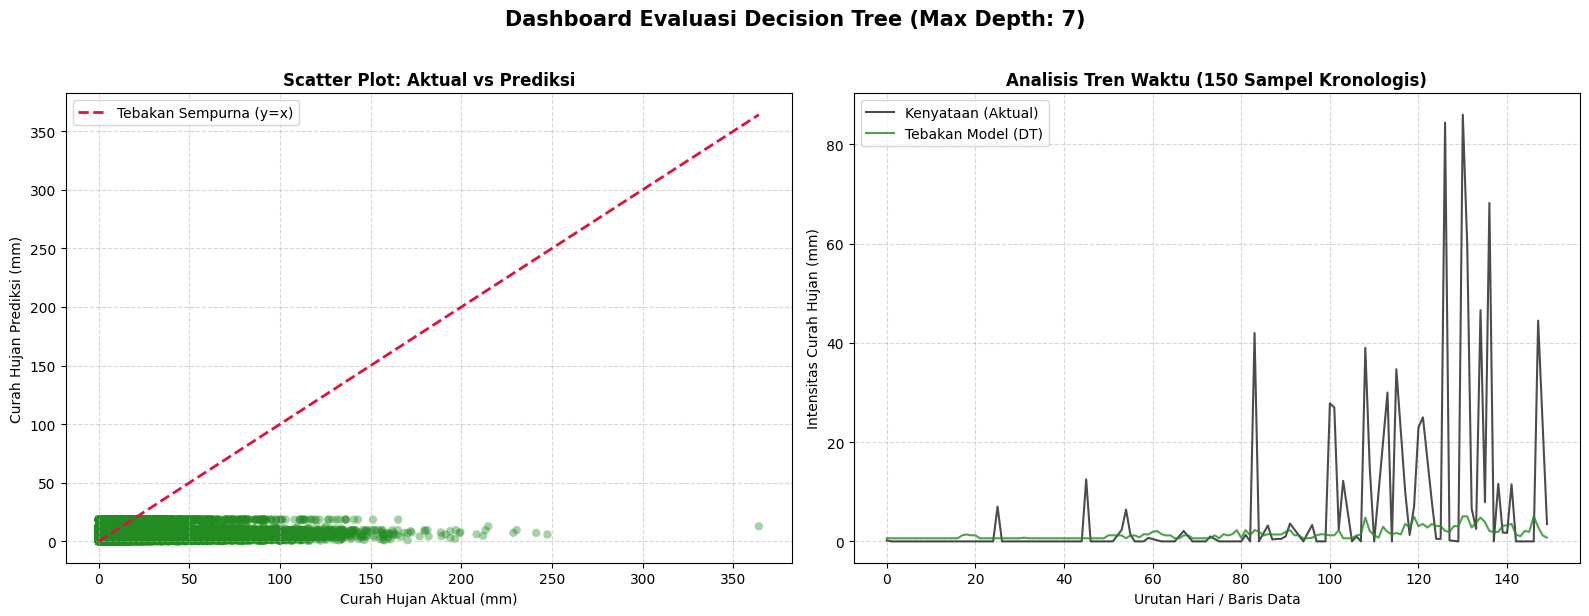

In [26]:

# Pastikan data berupa numpy array
y_val_asli_arr = np.array(y_val_asli)
y_pred_asli_arr = np.array(y_pred_asli_dt) # Menggunakan variabel prediksi Decision Tree

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFIK 1: SCATTER PLOT ---
axes[0].scatter(y_val_asli_arr, y_pred_asli_arr, alpha=0.4, color='forestgreen', edgecolors='none')
max_val = max(np.max(y_val_asli_arr), np.max(y_pred_asli_arr))
axes[0].plot([0, max_val], [0, max_val], color='crimson', linestyle='--', linewidth=2, label='Tebakan Sempurna (y=x)')
axes[0].set_title('Scatter Plot: Aktual vs Prediksi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Curah Hujan Aktual (mm)', fontsize=10)
axes[0].set_ylabel('Curah Hujan Prediksi (mm)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# --- GRAFIK 2: LINE PLOT ---
jumlah_sampel = 150
axes[1].plot(y_val_asli_arr[:jumlah_sampel], label='Kenyataan (Aktual)', color='black', alpha=0.7, linewidth=1.5)
axes[1].plot(y_pred_asli_arr[:jumlah_sampel], label='Tebakan Model (DT)', color='forestgreen', alpha=0.8, linewidth=1.5)
axes[1].set_title(f'Analisis Tren Waktu ({jumlah_sampel} Sampel Kronologis)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Urutan Hari / Baris Data', fontsize=10)
axes[1].set_ylabel('Intensitas Curah Hujan (mm)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.suptitle('Dashboard Evaluasi Decision Tree (Max Depth: 7)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

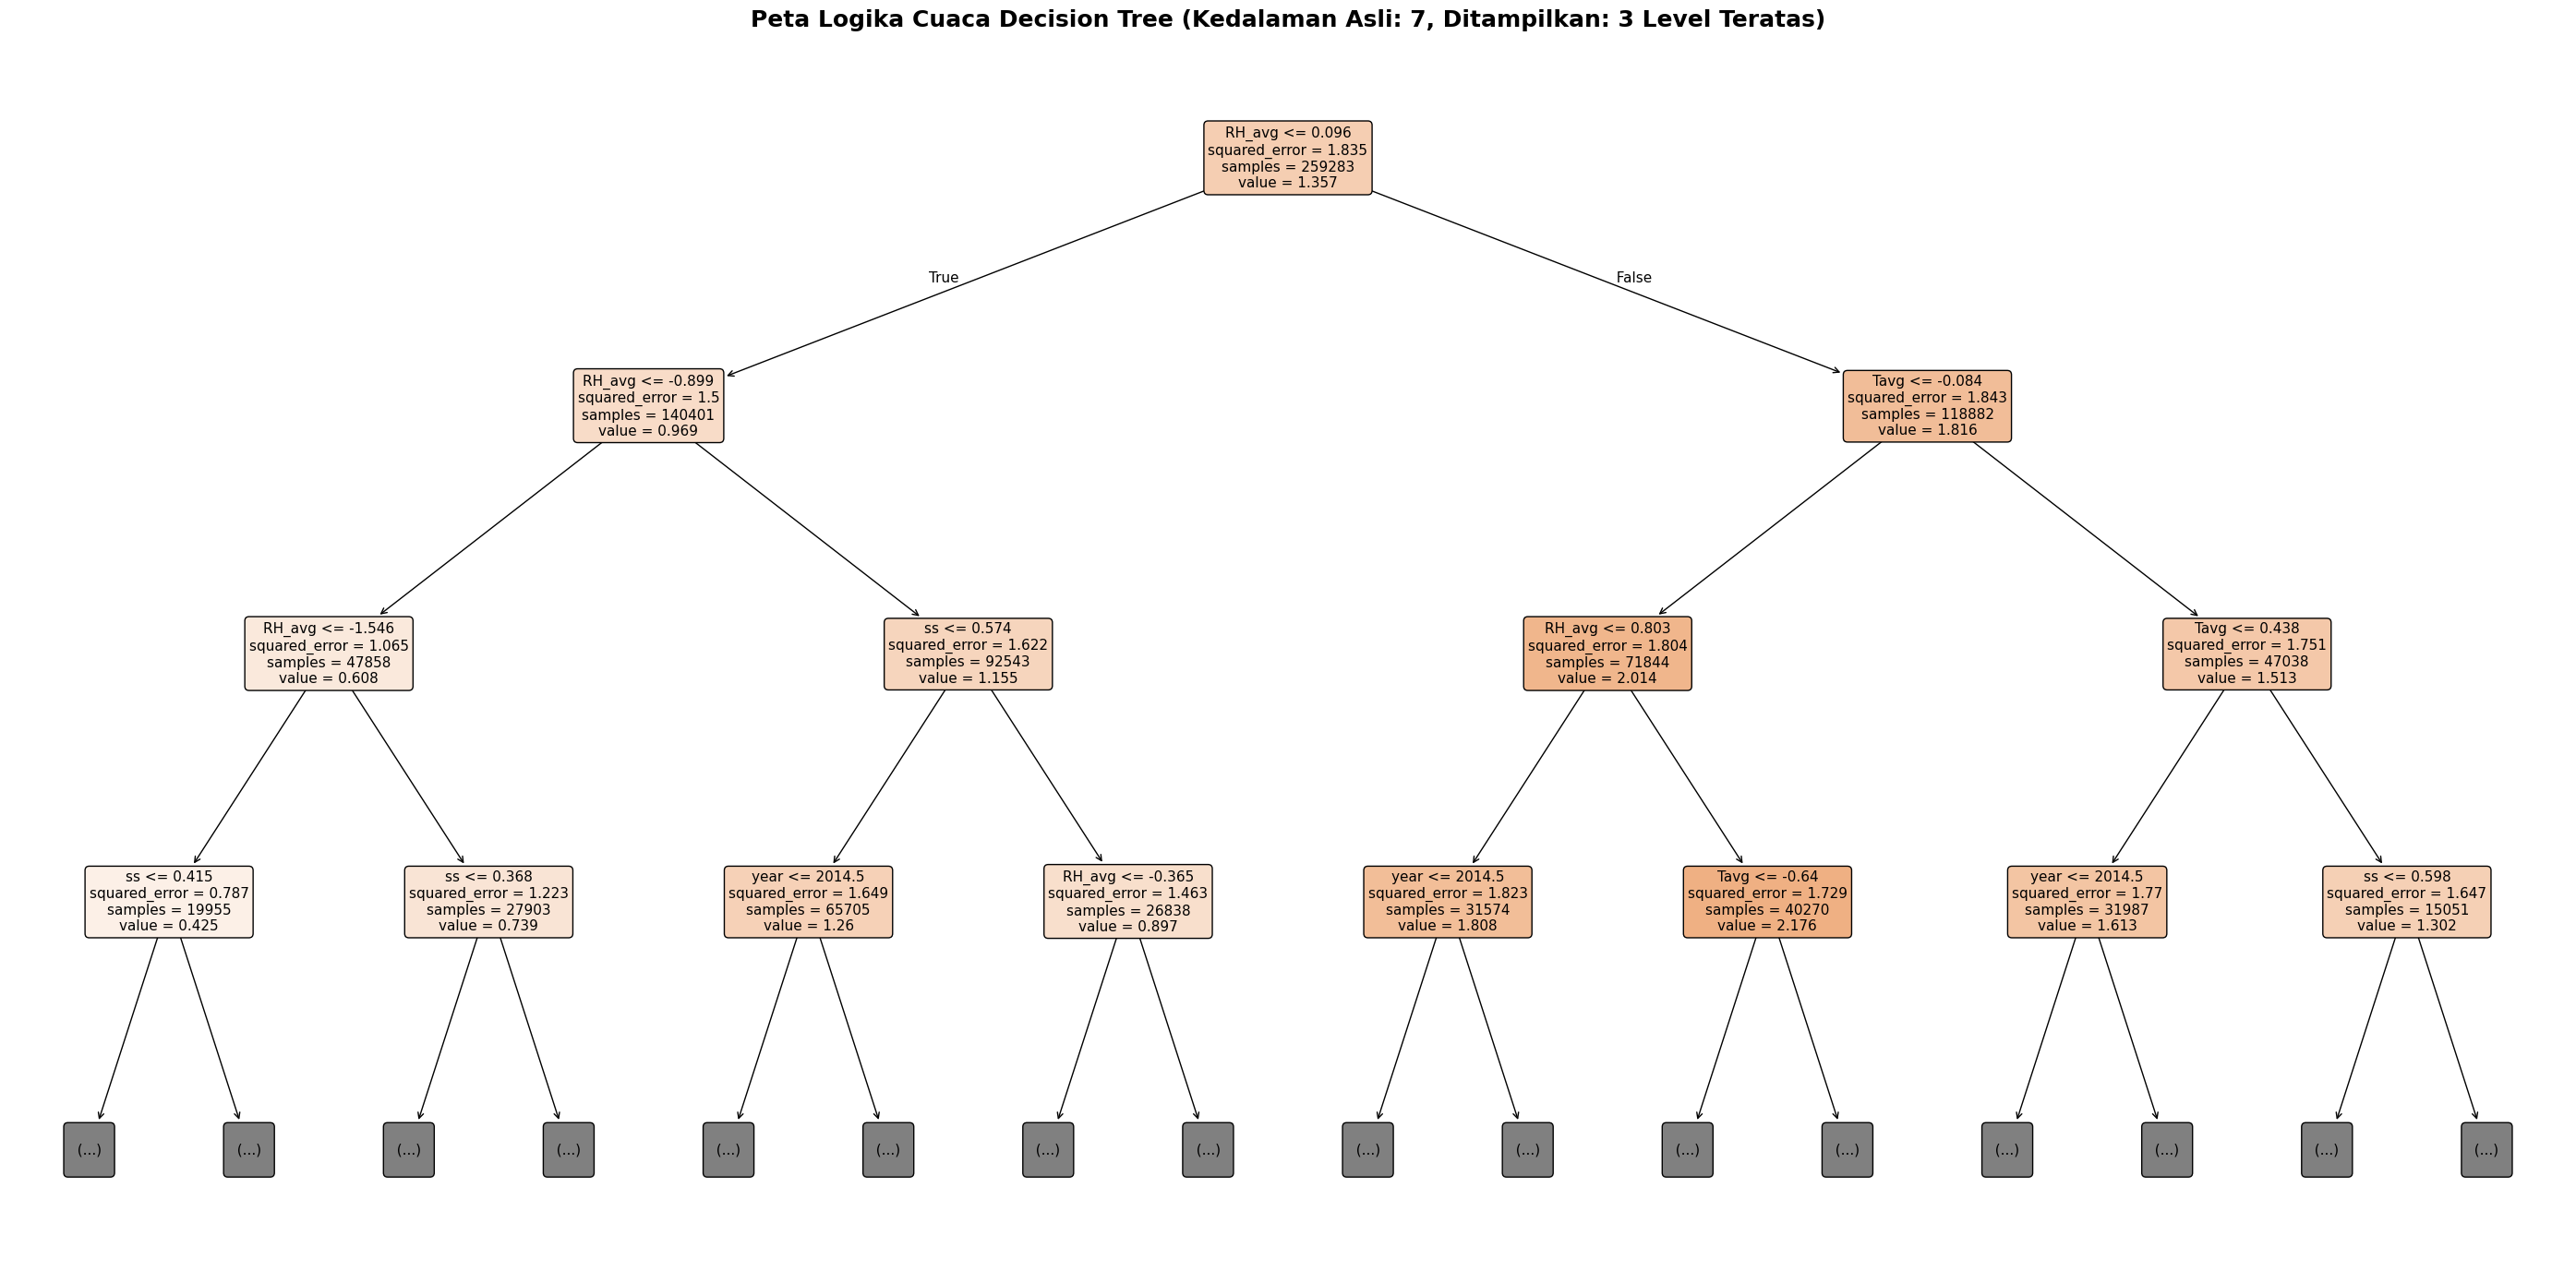

In [27]:
from sklearn.tree import plot_tree
plt.figure(figsize=(28, 14))

# Menggambar pohon
plot_tree(
    dt_model,
    feature_names=selected_features, # Menggunakan fitur yang lolos seleksi Lasso
    filled=True,                     # Mewarnai kotak berdasarkan nilainya
    rounded=True,                    # Membuat ujung kotak menjadi melengkung
    fontsize=11,                     # Ukuran teks (silakan diperkecil jika masih tumpang tindih)
    max_depth=3                      # BATAS VISUAL: Hanya menampilkan 3 cabang teratas agar terbaca
)

plt.title("Peta Logika Cuaca Decision Tree (Kedalaman Asli: 7, Ditampilkan: 3 Level Teratas)",
          fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =====================================================================
# 1. INISIALISASI RANDOM FOREST (DEEP TREE Blueprint)
# =====================================================================
rf_model = RandomForestRegressor(
    n_estimators=200,          # 200 pohon independen
    max_depth=None,            # Biarkan pohon tumbuh maksimal (wajib untuk RF!)
    min_samples_leaf=2,        # Rem sedikit di ujung daun agar anti-overfit
    max_features='sqrt',       # Mengambil akar kuadrat jumlah fitur agar bervariasi
    random_state=67,
    n_jobs=-1                  # Gunakan semua core prosesor
)

# =====================================================================
# 2. TRAINING (LANGSUNG PAKAI y_train YANG SUDAH BERBENTUK LOG)
# =====================================================================
print("⏳ Sedang melatih Random Forest tanpa jebakan double-log...")
# LANGSUNG gunakan y_train, jangan di-log1p lagi!
rf_model.fit(X_train_lasso, y_train)
print("✅ Pelatihan selesai!\n")

# =====================================================================
# 3. PREDIKSI & INVERSE LOG KE MILIMETER
# =====================================================================
y_pred_log_rf = rf_model.predict(X_val_lasso)
y_pred_asli_rf = np.expm1(y_pred_log_rf)

# Kita pastikan y_val_asli dikembalikan ke mm dengan benar dari y_val
y_val_asli = np.expm1(y_val)

# =====================================================================
# 4. EVALUASI RAPOR REALISTIS
# =====================================================================
mae_rf = mean_absolute_error(y_val_asli, y_pred_asli_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val_asli, y_pred_asli_rf))
r2_rf = r2_score(y_val_asli, y_pred_asli_rf)

print("=== RAPOR RANDOM FOREST (VERSI TOBAT LOG) ===")
print(f"MAE  (Rata-rata Meleset)     : {mae_rf:.2f} mm")
print(f"RMSE (Meleset Terburuk)      : {rmse_rf:.2f} mm")
print(f"R-squared (Skor Kecerdasan)  : {r2_rf:.4f}")

⏳ Sedang melatih Random Forest tanpa jebakan double-log...
✅ Pelatihan selesai!

=== RAPOR RANDOM FOREST (VERSI TOBAT LOG) ===
MAE  (Rata-rata Meleset)     : 7.16 mm
RMSE (Meleset Terburuk)      : 15.64 mm
R-squared (Skor Kecerdasan)  : 0.0075


⏳ Sedang memotret satu pohon dari dalam Random Forest...


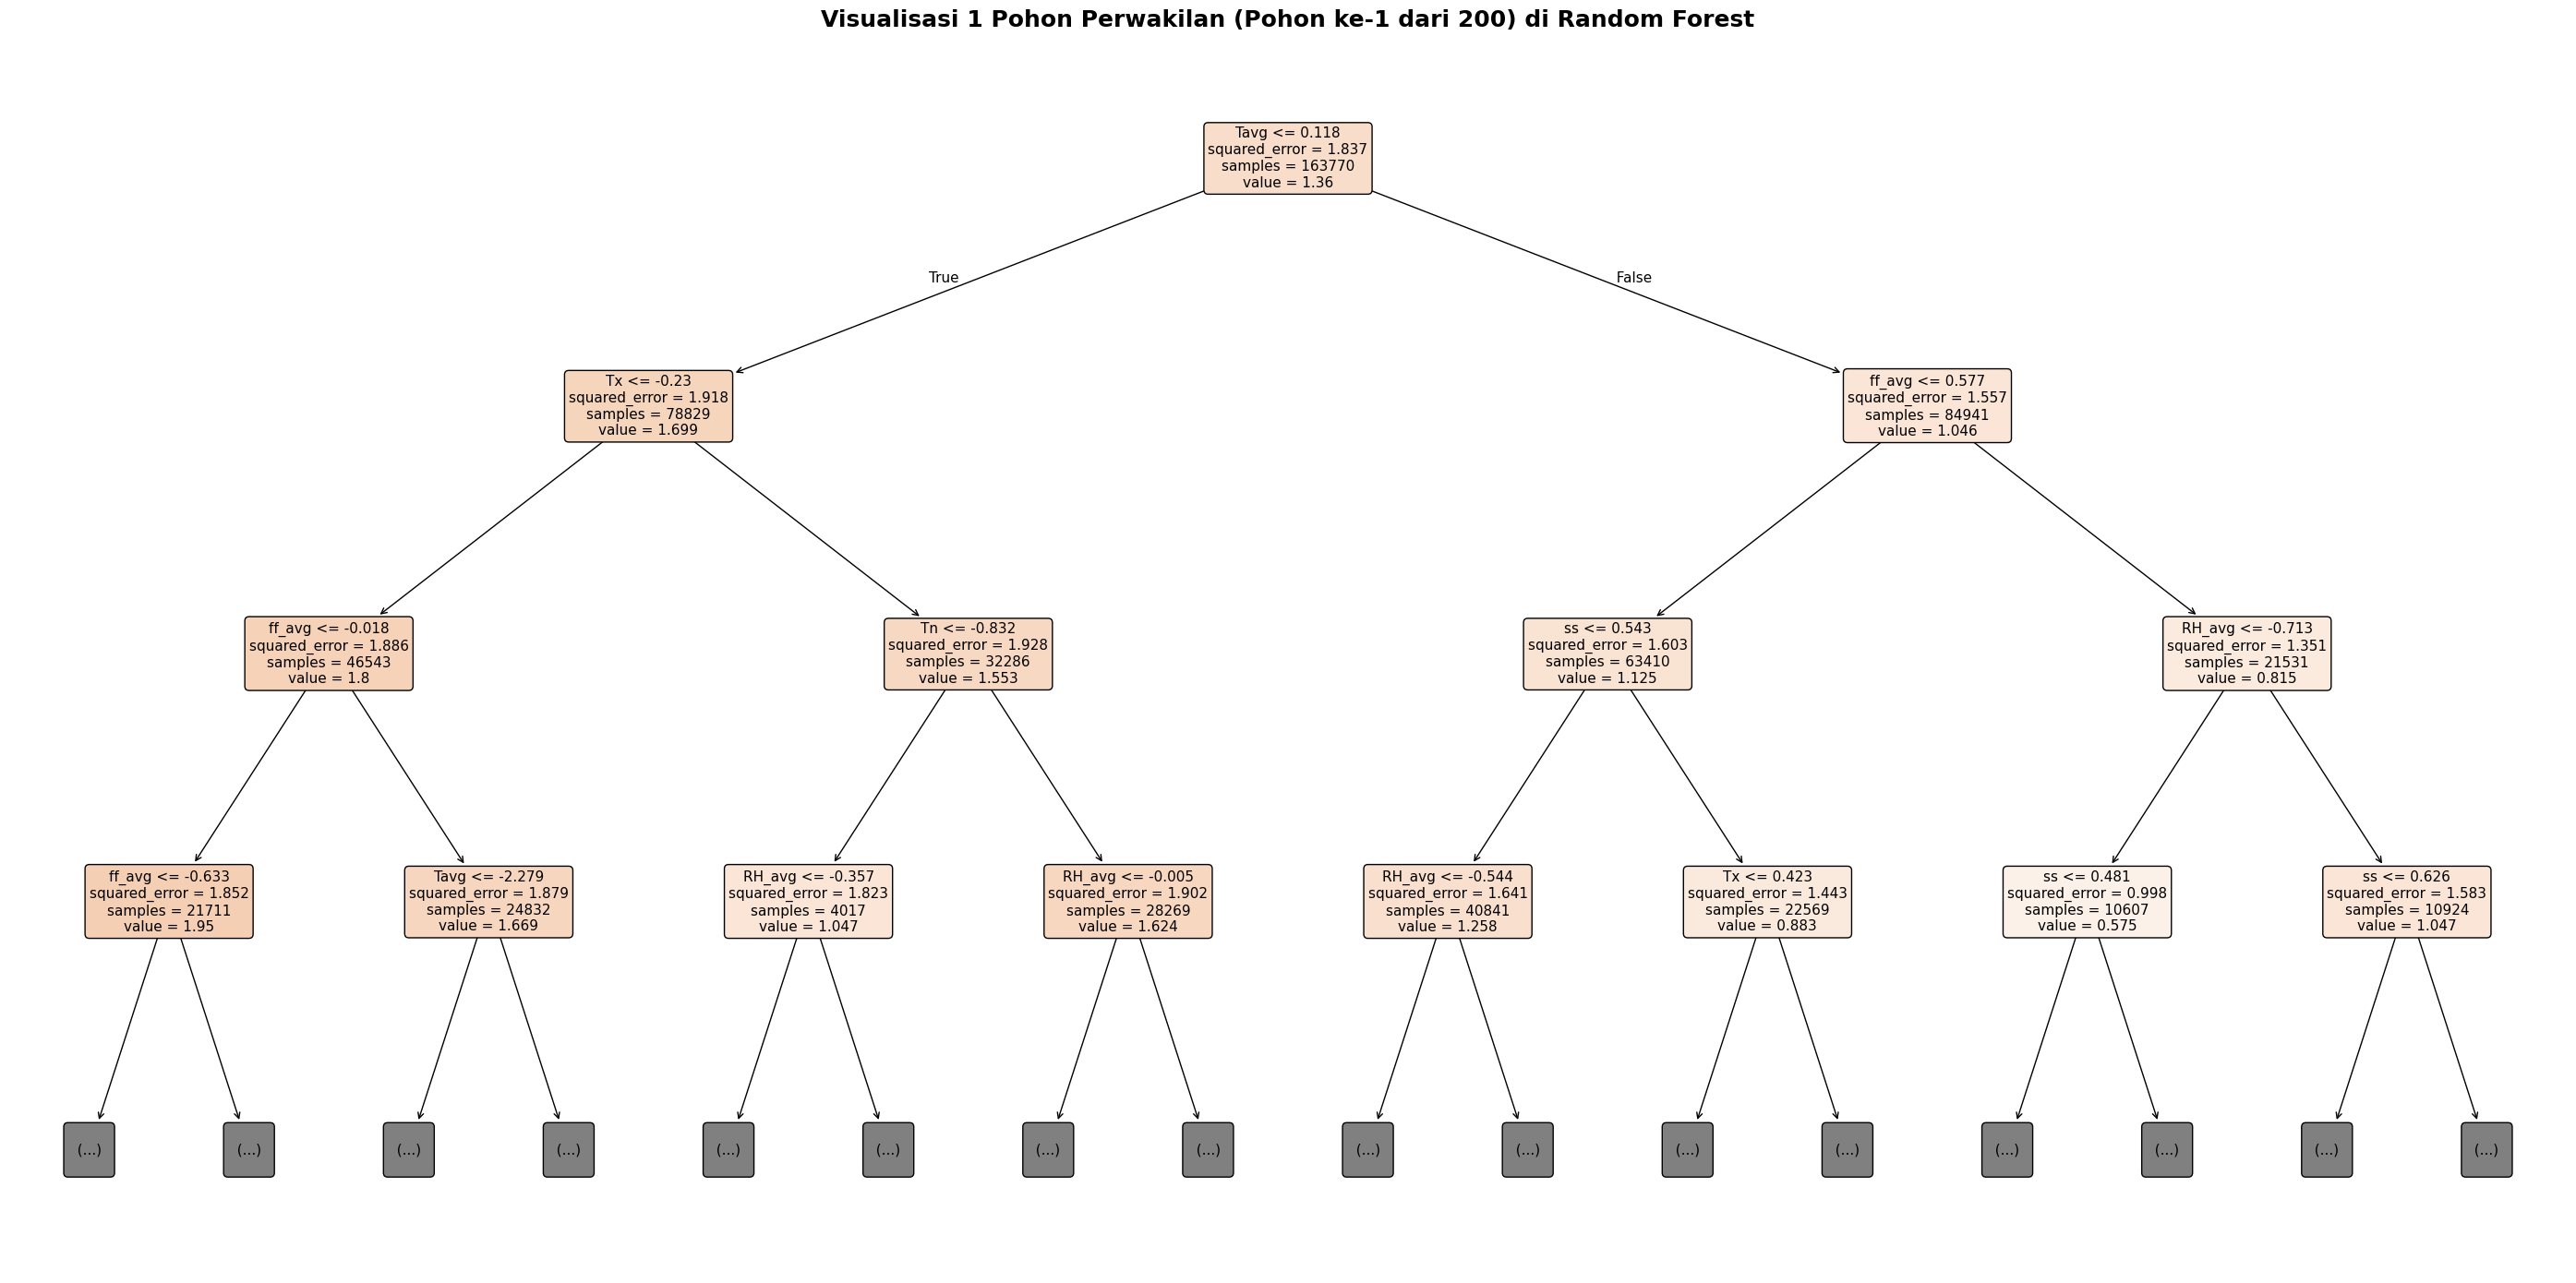

In [29]:
pohon_perwakilan = rf_model.estimators_[0]
plt.figure(figsize=(28, 14))

print("⏳ Sedang memotret satu pohon dari dalam Random Forest...")

# Menggambar pohon perwakilan
plot_tree(
    pohon_perwakilan,
    feature_names=selected_features, # Pastikan variabel ini masih tersimpan dari proses Lasso
    filled=True,
    rounded=True,
    fontsize=11,
    max_depth=3                      # BATAS VISUAL: Hanya tampilkan 3 level teratas agar terbaca
)

plt.title("Visualisasi 1 Pohon Perwakilan (Pohon ke-1 dari 200) di Random Forest", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Eksperiment hypertuning disini ya yang Gradient Bossting

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, make_scorer
import pandas as pd

def custom_mae(y_true_log, y_pred_log):
    y_true_asli = np.expm1(y_true_log)
    y_pred_asli = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_asli, y_pred_asli)

def custom_r2(y_true_log, y_pred_log):
    y_true_asli = np.expm1(y_true_log)
    y_pred_asli = np.expm1(y_pred_log)
    return r2_score(y_true_asli, y_pred_asli)

# Beri tahu sklearn: MAE makin kecil makin bagus (False), R2 makin besar makin bagus (True)
mae_scorer = make_scorer(custom_mae, greater_is_better=False)
r2_scorer = make_scorer(custom_r2, greater_is_better=True)

# 1. Inisiasi model dasar tanpa hyperparameter yang akan dituning
gb_base = GradientBoostingRegressor(max_features='sqrt', random_state=67)

# 2. Definisikan dictionary kombinasi Grid Search (Total 3x3x2x2 = 36 kombinasi)
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

print("⏳ Memulai eksperimen Grid Search CV untuk Gradient Boosting...")
print("Mengeksekusi 36 kombinasi dengan 5-Fold CV (Total 180 proses training). Harap tunggu...")

# 3. Konfigurasi GridSearchCV
# Catatan: Karena y_train kalian berada dalam skala log, skor MAE dan R2 ini
# akan mengukur error di skala log. Ini wajar untuk seleksi model terbaik di GridSearch.
grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=5,                             # 5-fold cross-validation
    scoring={'MAE': mae_scorer, 'R2': r2_scorer},
    refit='R2',                       # Pilih model terbaik berdasarkan R2
    return_train_score=True,          # Ambil skor training juga
    n_jobs=-1                         # Pakai seluruh core CPU (-1)
)

# 4. Fit model dengan X_train yang sudah diseleksi Lasso
grid_search.fit(X_train_lasso, y_train)

print("✅ Grid Search selesai!")
print(f"🌟 Parameter Terbaik: {grid_search.best_params_}")

# 5. Ekstrak hasil ke DataFrame pandas
results_df = pd.DataFrame(grid_search.cv_results_)

# Pilih kolom yang penting saja dan ganti namanya agar lebih enak dibaca di Excel
columns_to_keep = {
    'param_learning_rate': 'learning_rate',
    'param_n_estimators': 'n_estimators',
    'param_max_depth': 'max_depth',
    'param_subsample': 'subsample',
    'mean_train_MAE': 'mean_train_mae',
    'mean_test_MAE': 'mean_test_mae',  # test_ di sini maksudnya nilai MAE fold validasi (CV)
    'mean_train_R2': 'mean_train_r2',
    'mean_test_R2': 'mean_test_r2'
}

final_excel_dataframe = results_df[list(columns_to_keep.keys())].rename(columns=columns_to_keep)

# Scikit-learn menggunakan nilai negatif untuk error function (semakin mendekati 0 semakin baik)
# Kita absolut-kan / mutlak-kan biar balik jadi nilai error normal buat dipamerin ke dosen
final_excel_dataframe['mean_train_mae'] = final_excel_dataframe['mean_train_mae'].abs()
final_excel_dataframe['mean_test_mae'] = final_excel_dataframe['mean_test_mae'].abs()

# 6. Simpan ke File Excel dan Download
excel_filename = 'gradient_boosting_experiments.xlsx'
final_excel_dataframe.to_excel(excel_filename, index=False)
print(f"📊 File Excel eksperimen berhasil disimpan: {excel_filename}")

# Block try-except ini berfungsi untuk men-download file ke komputer lokal
# kalau kamu nge-run script ini di Google Colab.
try:
    from google.colab import files
    files.download(excel_filename)
    print("Mendownload file excel otomatis ke komputer Anda...")
except ImportError:
    pass # Akan di-skip jika dijalankan di lokal/Jupyter biasa, bukan di Google Colab

⏳ Memulai eksperimen Grid Search CV untuk Gradient Boosting...
Mengeksekusi 36 kombinasi dengan 5-Fold CV (Total 180 proses training). Harap tunggu...
✅ Grid Search selesai!
🌟 Parameter Terbaik: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 500, 'subsample': 1.0}
📊 File Excel eksperimen berhasil disimpan: gradient_boosting_experiments.xlsx


In [32]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =====================================================================
# 1. INISIALISASI MODEL SANG JUARA (TUNED GRADIENT BOOSTING)
# =====================================================================
# Memasukkan best_params_ dari hasil Grid Search
gb_tuned = GradientBoostingRegressor(
    learning_rate=0.2,
    max_depth=5,
    n_estimators=500,
    subsample=1.0,
    max_features='sqrt',  # Ingat, ini bawaan model awalmu, jangan dibuang!
    random_state=67       # Kunci seed agar hasilnya konsisten saat di-run ulang
)

# =====================================================================
# 2. MELATIH ULANG SANG JUARA (Di Data Latih)
# =====================================================================
print("⏳ Sedang melatih model Juara dengan hyperparameter terbaik...")
gb_tuned.fit(X_train_lasso, y_train)
print("✅ Pelatihan selesai!\n")

# =====================================================================
# 3. UJIAN TAHAP 1: VALIDATION SET (Try Out Akhir)
# =====================================================================
# Prediksi (hasilnya masih dalam skala log)
y_pred_log_val = gb_tuned.predict(X_val_lasso)

# Kembalikan ke milimeter asli
y_pred_asli_val = np.expm1(y_pred_log_val)
y_val_asli = np.expm1(y_val)

# Evaluasi Rapor Validasi
mae_val = mean_absolute_error(y_val_asli, y_pred_asli_val)
rmse_val = np.sqrt(mean_squared_error(y_val_asli, y_pred_asli_val))
r2_val = r2_score(y_val_asli, y_pred_asli_val)

# =====================================================================
# 4. UJIAN TAHAP 2: TESTING SET (Ujian Nasional)
# =====================================================================
# Prediksi (hasilnya masih dalam skala log)
y_pred_log_test = gb_tuned.predict(X_test_lasso)

# Kembalikan ke milimeter asli
y_pred_asli_test = np.expm1(y_pred_log_test)
y_test_asli = np.expm1(y_test)

# Evaluasi Rapor Testing
mae_test = mean_absolute_error(y_test_asli, y_pred_asli_test)
rmse_test = np.sqrt(mean_squared_error(y_test_asli, y_pred_asli_test))
r2_test = r2_score(y_test_asli, y_pred_asli_test)

# =====================================================================
# 5. TAMPILKAN HASILNYA SEBAGAI BUKTI SKRIPSI / LAPORAN
# =====================================================================
print("🏆 === RAPOR FINAL: TUNED GRADIENT BOOSTING === 🏆\n")

print("📊 HASIL UJIAN VALIDATION SET (25% Data Tengah):")
print(f"MAE  (Rata-rata Meleset)     : {mae_val:.2f} mm")
print(f"RMSE (Meleset Terburuk)      : {rmse_val:.2f} mm")
print(f"R-squared (Skor Kecerdasan)  : {r2_val:.4f}\n")

print("🎓 HASIL UJIAN TESTING SET (25% Data Masa Depan):")
print(f"MAE  (Rata-rata Meleset)     : {mae_test:.2f} mm")
print(f"RMSE (Meleset Terburuk)      : {rmse_test:.2f} mm")
print(f"R-squared (Skor Kecerdasan)  : {r2_test:.4f}")

⏳ Sedang melatih model Juara dengan hyperparameter terbaik...
✅ Pelatihan selesai!

🏆 === RAPOR FINAL: TUNED GRADIENT BOOSTING === 🏆

📊 HASIL UJIAN VALIDATION SET (25% Data Tengah):
MAE  (Rata-rata Meleset)     : 7.15 mm
RMSE (Meleset Terburuk)      : 15.55 mm
R-squared (Skor Kecerdasan)  : 0.0178

🎓 HASIL UJIAN TESTING SET (25% Data Masa Depan):
MAE  (Rata-rata Meleset)     : 7.23 mm
RMSE (Meleset Terburuk)      : 15.80 mm
R-squared (Skor Kecerdasan)  : 0.0270


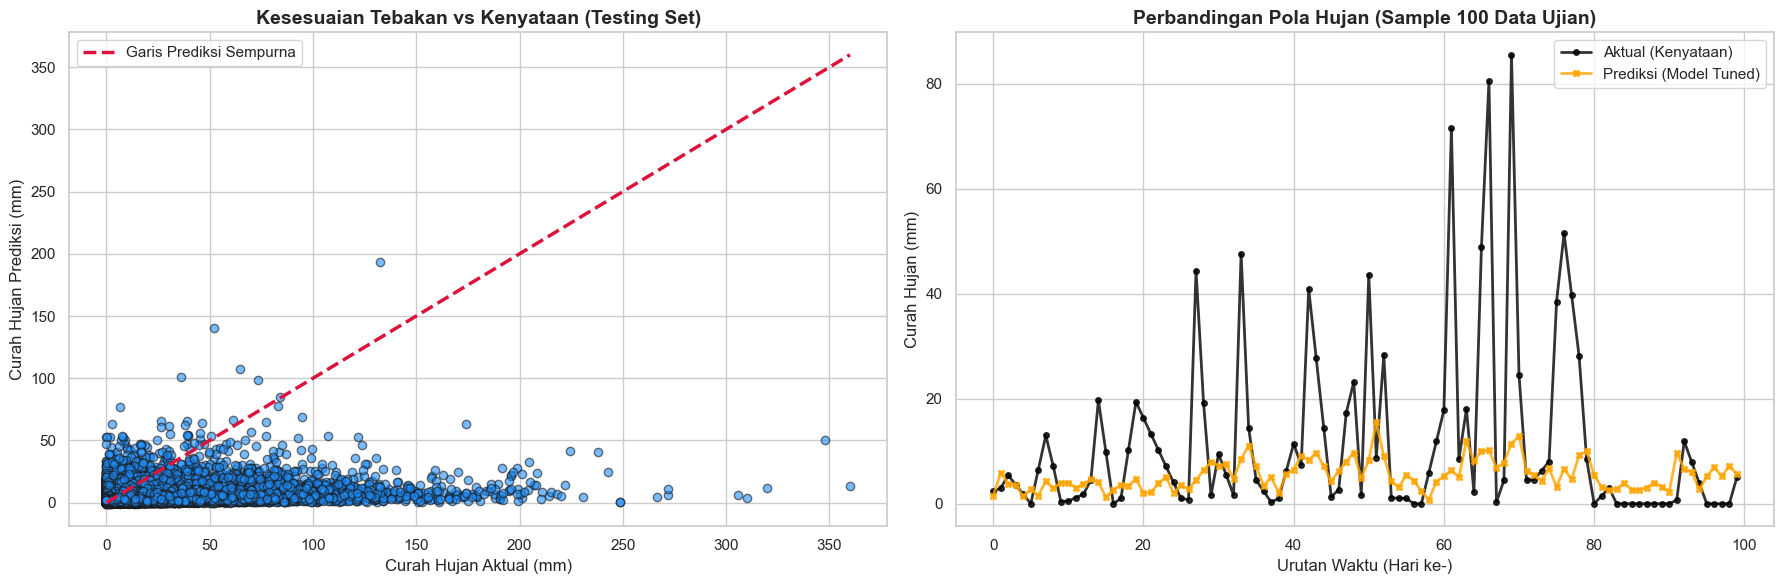

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# VISUALISASI HASIL TESTING SET (UJIAN NASIONAL)
# =====================================================================
# Mengatur tema agar grafiknya terlihat elegan dan akademis
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ---------------------------------------------------------------------
# GRAFIK 1: Scatter Plot (Aktual vs Prediksi)
# ---------------------------------------------------------------------
# Menggambar titik-titik prediksi vs aktual
axes[0].scatter(y_test_asli, y_pred_asli_test, alpha=0.6, color='dodgerblue', edgecolor='k')

# Membuat garis diagonal merah (Garis Sempurna / Skenario Impian)
max_val = max(y_test_asli.max(), y_pred_asli_test.max())
axes[0].plot([0, max_val], [0, max_val], color='crimson', linestyle='--', linewidth=2.5, 
             label='Garis Prediksi Sempurna')

axes[0].set_title("Kesesuaian Tebakan vs Kenyataan (Testing Set)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Curah Hujan Aktual (mm)", fontsize=12)
axes[0].set_ylabel("Curah Hujan Prediksi (mm)", fontsize=12)
axes[0].legend()

# ---------------------------------------------------------------------
# GRAFIK 2: Line Plot (Tren Waktu)
# ---------------------------------------------------------------------
# Karena data testing mungkin ada ratusan baris, kita ambil 100 hari pertama saja 
# agar grafiknya tidak terlalu ruwet seperti benang kusut.
batas_visual = 100 

# y_test_asli biasanya berupa Pandas Series, jadi kita gunakan .values agar aman saat di-plot
axes[1].plot(y_test_asli.values[:batas_visual], label='Aktual (Kenyataan)', 
             color='black', alpha=0.8, linewidth=2, marker='o', markersize=4)
axes[1].plot(y_pred_asli_test[:batas_visual], label='Prediksi (Model Tuned)', 
             color='orange', alpha=0.8, linewidth=2, marker='X', markersize=5)

axes[1].set_title(f"Perbandingan Pola Hujan (Sample {batas_visual} Data Ujian)", 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel("Urutan Waktu (Hari ke-)", fontsize=12)
axes[1].set_ylabel("Curah Hujan (mm)", fontsize=12)
axes[1].legend()

# Menampilkan grafik dengan rapi
plt.tight_layout()
plt.show()

⏳ Sedang melatih Model Standar...
⏳ Sedang melatih Model Tuned (Juara)...
✅ Pelatihan kedua model selesai!

🏆 === TABEL PERBANDINGAN SEBELUM VS SESUDAH TUNING === 🏆


,Metrik Ujian,Sebelum Tuning (Standar),Sesudah Tuning (Juara),Selisih
0,MAE Validation (mm) ↓,7.1377,7.1485,0.0108
1,RMSE Validation (mm) ↓,15.5417,15.5540,0.0123
2,R-Squared Validation ↑,0.0193,0.0178,-0.0015
3,MAE Testing (mm) ↓,7.2125,7.2253,0.0128
4,RMSE Testing (mm) ↓,15.7814,15.8020,0.0206
5,R-Squared Testing ↑,0.0295,0.0270,-0.0025


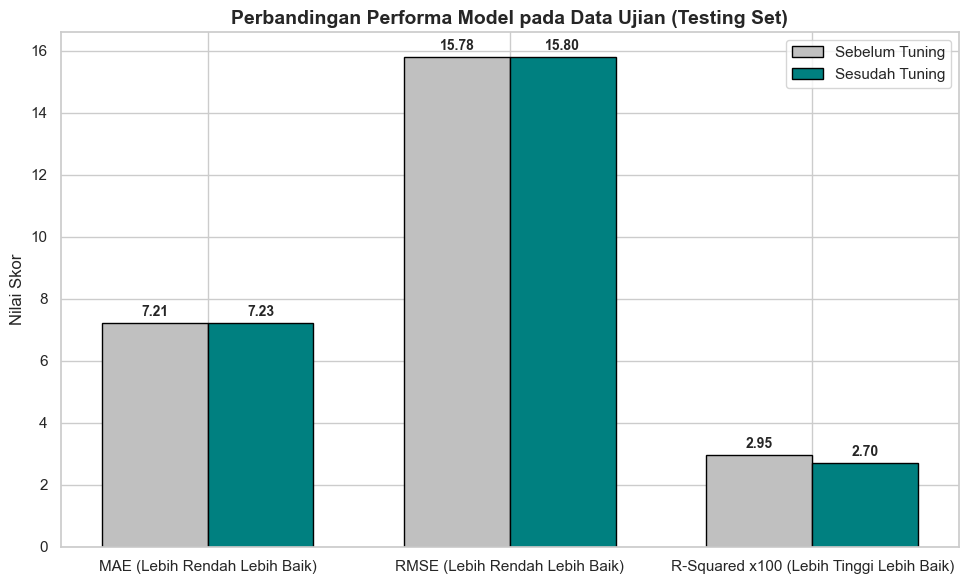

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# 1. INISIALISASI KEDUA MODEL (STANDAR VS TUNED)
# =====================================================================
# Model 1: Standar (Tebakan awal)
gb_standar = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.1, max_depth=7, 
    min_samples_leaf=5, subsample=0.8, max_features='sqrt', random_state=67
)

# Model 2: Tuned (Juara Grid Search)
gb_tuned = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.2, max_depth=5, 
    subsample=1.0, max_features='sqrt', random_state=67
)

# =====================================================================
# 2. PELATIHAN KEDUA MODEL
# =====================================================================
print("⏳ Sedang melatih Model Standar...")
gb_standar.fit(X_train_lasso, y_train)

print("⏳ Sedang melatih Model Tuned (Juara)...")
gb_tuned.fit(X_train_lasso, y_train)
print("✅ Pelatihan kedua model selesai!\n")

# =====================================================================
# 3. FUNGSI EVALUASI (Inverse Log Otomatis)
# =====================================================================
def evaluasi_model(model, X_data, y_true_log):
    # Prediksi
    y_pred_log = model.predict(X_data)
    # Kembalikan ke mm
    y_pred_asli = np.expm1(y_pred_log)
    y_true_asli = np.expm1(y_true_log)
    
    # Hitung metrik
    mae = mean_absolute_error(y_true_asli, y_pred_asli)
    rmse = np.sqrt(mean_squared_error(y_true_asli, y_pred_asli))
    r2 = r2_score(y_true_asli, y_pred_asli)
    return mae, rmse, r2

# Evaluasi Standar
mae_val_std, rmse_val_std, r2_val_std = evaluasi_model(gb_standar, X_val_lasso, y_val)
mae_test_std, rmse_test_std, r2_test_std = evaluasi_model(gb_standar, X_test_lasso, y_test)

# Evaluasi Tuned
mae_val_tnd, rmse_val_tnd, r2_val_tnd = evaluasi_model(gb_tuned, X_val_lasso, y_val)
mae_test_tnd, rmse_test_tnd, r2_test_tnd = evaluasi_model(gb_tuned, X_test_lasso, y_test)

# =====================================================================
# 4. MEMBUAT TABEL PERBANDINGAN (DATAFRAME)
# =====================================================================
perbandingan_df = pd.DataFrame({
    'Metrik Ujian': [
        'MAE Validation (mm) ↓', 'RMSE Validation (mm) ↓', 'R-Squared Validation ↑',
        'MAE Testing (mm) ↓', 'RMSE Testing (mm) ↓', 'R-Squared Testing ↑'
    ],
    'Sebelum Tuning (Standar)': [
        mae_val_std, rmse_val_std, r2_val_std, 
        mae_test_std, rmse_test_std, r2_test_std
    ],
    'Sesudah Tuning (Juara)': [
        mae_val_tnd, rmse_val_tnd, r2_val_tnd, 
        mae_test_tnd, rmse_test_tnd, r2_test_tnd
    ]
})

# Menghitung selisih (Improvment)
perbandingan_df['Selisih'] = perbandingan_df['Sesudah Tuning (Juara)'] - perbandingan_df['Sebelum Tuning (Standar)']

print("🏆 === TABEL PERBANDINGAN SEBELUM VS SESUDAH TUNING === 🏆")
# Print rapi dengan membulatkan 4 angka di belakang koma
display(perbandingan_df.round(4)) 

# =====================================================================
# 5. VISUALISASI GRAFIK PERBANDINGAN UNTUK TESTING SET
# =====================================================================
labels = ['MAE (Lebih Rendah Lebih Baik)', 'RMSE (Lebih Rendah Lebih Baik)', 'R-Squared x100 (Lebih Tinggi Lebih Baik)']
std_scores = [mae_test_std, rmse_test_std, r2_test_std * 100] # R2 dikali 100 agar terlihat di grafik bersanding dengan MAE/RMSE
tnd_scores = [mae_test_tnd, rmse_test_tnd, r2_test_tnd * 100]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, std_scores, width, label='Sebelum Tuning', color='silver', edgecolor='black')
rects2 = ax.bar(x + width/2, tnd_scores, width, label='Sesudah Tuning', color='teal', edgecolor='black')

ax.set_ylabel('Nilai Skor', fontsize=12)
ax.set_title('Perbandingan Performa Model pada Data Ujian (Testing Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()

# Menambahkan angka di atas batang grafik
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 poin ke atas
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()